# 🥇 Gold ETF & Gold Returns — Comprehensive Analysis
### *Why did Gold prices increase? Who drove it — Central Banks or ETFs?*

---
**Dataset:** Monthly Gold ETF, Central Bank Demand, Macro Variables  
**Period:** January 2020 – April 2026  
**Objective:** Infer and explain drivers of Gold Returns using statistical & econometric methods

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests, coint
from statsmodels.stats.stattools import durbin_watson
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from statsmodels.tsa.api import VAR
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d0d0d',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#e0e0e0',
    'axes.titlecolor':  '#ffffff',
    'xtick.color':      '#bbbbbb',
    'ytick.color':      '#bbbbbb',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2a4a',
    'grid.alpha':       0.6,
    'figure.dpi':       110,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

GOLD   = '#FFD700'
BLUE   = '#4FC3F7'
GREEN  = '#69F0AE'
RED    = '#FF6B6B'
PURPLE = '#CE93D8'
ORANGE = '#FFAB40'

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


In [12]:
# ── Load & Clean Data ──────────────────────────────────────────────────────────
df = pd.read_excel('Gold ETF.xlsx')
df.columns = [
    'Date', 'North_America', 'Europe', 'Asia', 'Others',
    'ETF_Demand', 'CPI', 'SP500_Return', 'USD_Index',
    'Treasury_Yield', 'Oil_Price', 'FED_Rate',
    'CB_Demand', 'Total_Demand', 'Gold_Returns'
]
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f'Data shape   : {df.shape}')
print(f'Date range   : {df.Date.min().strftime("%b %Y")} → {df.Date.max().strftime("%b %Y")}')
print(f'Null values  :')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\n📊 Summary statistics:')
df.describe().round(2)

Data shape   : (76, 15)
Date range   : Jan 2020 → Apr 2026
Null values  :
Series([], dtype: int64)

📊 Summary statistics:


,Date,North_America,Europe,Asia,Others,ETF_Demand,CPI,SP500_Return,USD_Index,Treasury_Yield,Oil_Price,FED_Rate,CB_Demand,Total_Demand,Gold_Returns
count,76,76.00,76.00,76.00,76.00,76.00,76.00,76.00,76.00,76.00,76.00,76.00,76.00,76.00,76.00
mean,2023-02-15 03:47:22.105263104,7.48,1.15,5.66,0.42,14.71,0.35,1.18,119.59,3.02,70.82,2.80,27.77,42.47,1.61
min,2020-01-01 00:00:00,-87.00,-52.10,-9.90,-4.00,-107.50,-0.68,-12.51,110.76,0.55,19.23,0.05,-63.10,-136.22,-5.66
25%,2021-07-24 06:00:00,-22.60,-14.18,0.08,-0.40,-33.43,0.10,-1.88,116.19,1.52,61.70,0.09,8.48,1.00,-0.88
50%,2023-02-15 00:00:00,6.70,-0.50,2.35,0.30,13.70,0.32,1.96,120.22,3.81,72.16,3.68,26.24,36.98,0.90
75%,2024-09-08 12:00:00,31.50,17.58,7.42,1.05,46.85,0.55,4.45,122.15,4.21,80.77,4.70,43.80,83.27,4.10
max,2026-04-01 00:00:00,144.20,84.30,69.60,4.70,187.30,1.38,12.68,129.28,4.88,114.38,5.33,166.31,194.22,10.66
std,NaN,43.32,25.56,12.87,1.42,65.82,0.38,4.99,4.35,1.42,19.15,2.18,33.52,65.30,3.60


---
## 1. Gold ETF Demand Trend Analysis

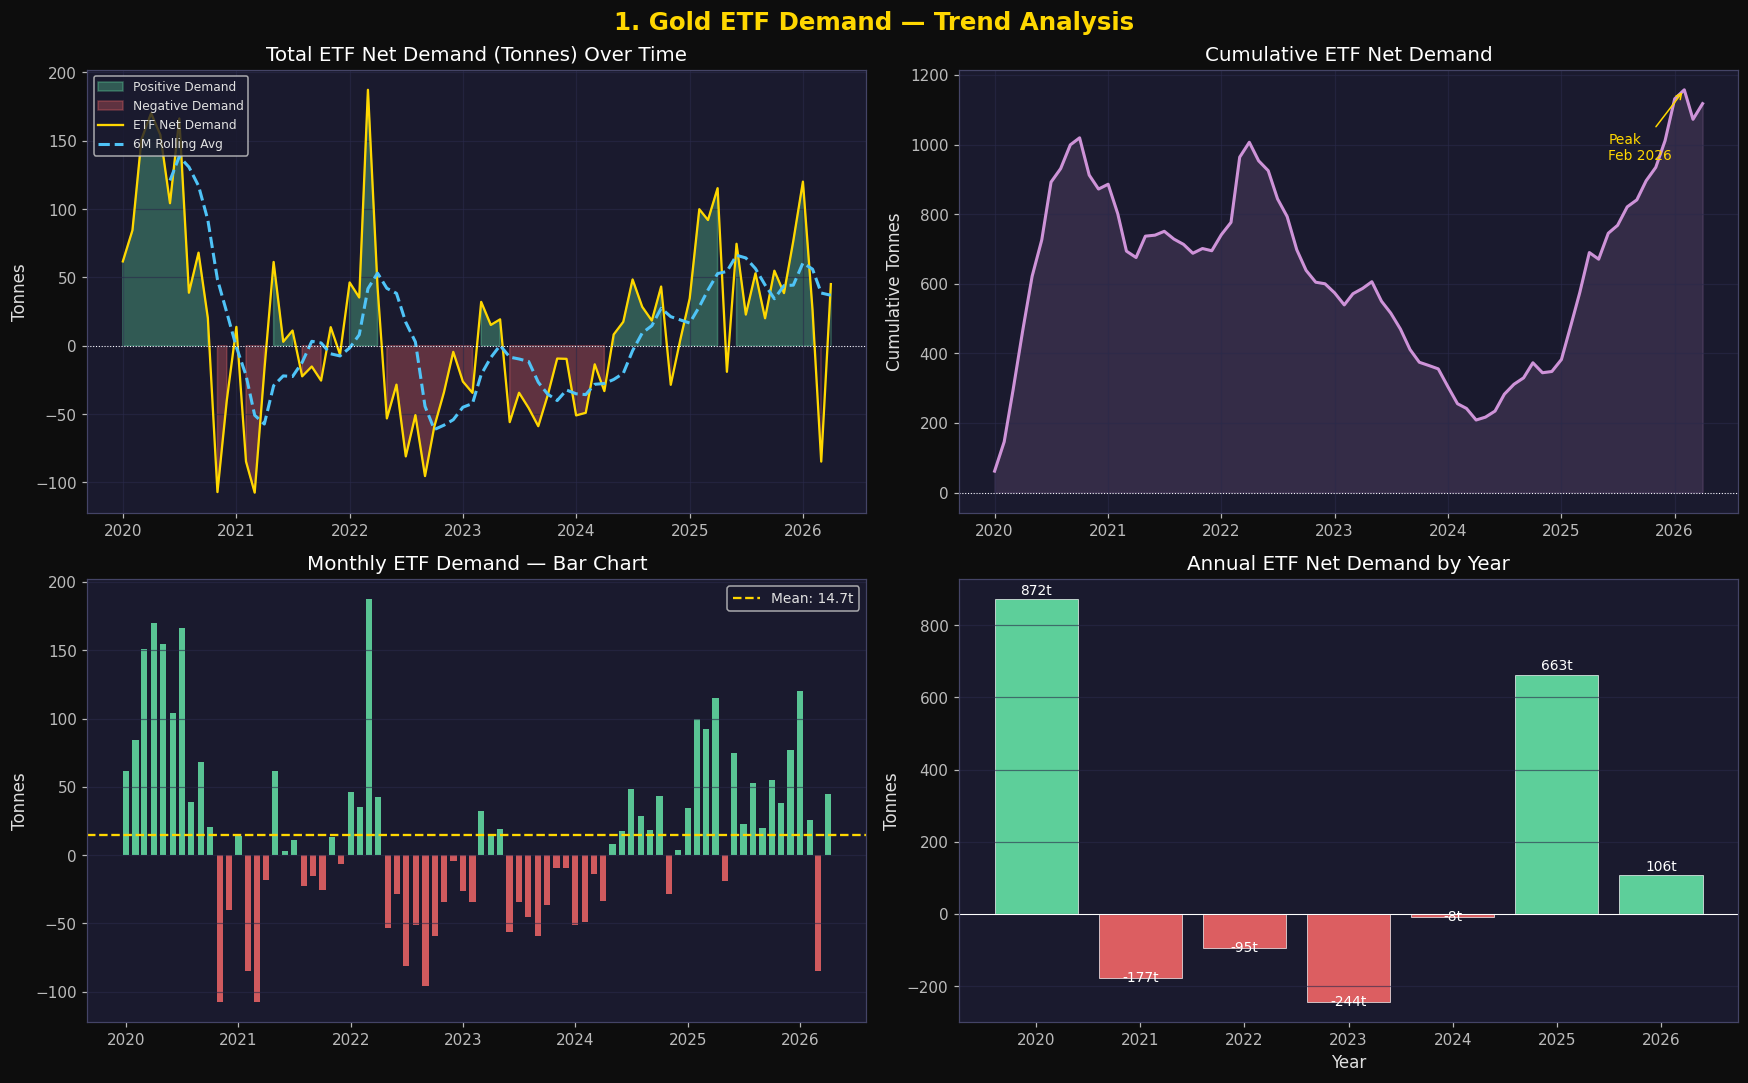


📌 KEY INSIGHTS:
  • Total ETF demand 2020-2026 : 1117.6 tonnes
  • Best month  : Mar 2022 (187.3t)
  • Worst month : Mar 2021 (-107.5t)
  • Months with positive demand: 43 / 76


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('1. Gold ETF Demand — Trend Analysis', fontsize=16, fontweight='bold', color=GOLD, y=0.98)

# --- Row 1 Col 1: ETF Demand Line + Rolling Mean ---
ax = axes[0, 0]
ax.fill_between(df.Date, df.ETF_Demand, where=df.ETF_Demand >= 0,
                color=GREEN, alpha=0.3, label='Positive Demand')
ax.fill_between(df.Date, df.ETF_Demand, where=df.ETF_Demand < 0,
                color=RED, alpha=0.3, label='Negative Demand')
ax.plot(df.Date, df.ETF_Demand, color=GOLD, linewidth=1.5, label='ETF Net Demand')
roll = df.ETF_Demand.rolling(6).mean()
ax.plot(df.Date, roll, color=BLUE, linewidth=2, linestyle='--', label='6M Rolling Avg')
ax.axhline(0, color='white', linewidth=0.7, linestyle=':')
ax.set_title('Total ETF Net Demand (Tonnes) Over Time')
ax.set_ylabel('Tonnes')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True)

# --- Row 1 Col 2: Cumulative ETF Demand ---
ax = axes[0, 1]
cumulative = df.ETF_Demand.cumsum()
ax.plot(df.Date, cumulative, color=PURPLE, linewidth=2)
ax.fill_between(df.Date, cumulative, color=PURPLE, alpha=0.15)
ax.axhline(0, color='white', linewidth=0.7, linestyle=':')
peak_idx = cumulative.idxmax()
ax.annotate(f'Peak\n{df.Date[peak_idx].strftime("%b %Y")}',
            xy=(df.Date[peak_idx], cumulative[peak_idx]),
            xytext=(df.Date[peak_idx] - pd.DateOffset(months=8), cumulative[peak_idx] - 200),
            arrowprops=dict(arrowstyle='->', color=GOLD), color=GOLD, fontsize=9)
ax.set_title('Cumulative ETF Net Demand')
ax.set_ylabel('Cumulative Tonnes')
ax.grid(True)

# --- Row 2 Col 1: ETF Monthly Distribution ---
ax = axes[1, 0]
colors = [GREEN if v >= 0 else RED for v in df.ETF_Demand]
ax.bar(df.Date, df.ETF_Demand, color=colors, alpha=0.8, width=20)
ax.axhline(df.ETF_Demand.mean(), color=GOLD, linewidth=1.5, linestyle='--',
           label=f'Mean: {df.ETF_Demand.mean():.1f}t')
ax.set_title('Monthly ETF Demand — Bar Chart')
ax.set_ylabel('Tonnes')
ax.legend(fontsize=9)
ax.grid(True, axis='y')

# --- Row 2 Col 2: Yearly ETF aggregated ---
ax = axes[1, 1]
yearly = df.groupby(df.Date.dt.year)['ETF_Demand'].sum()
bar_colors = [GREEN if v >= 0 else RED for v in yearly]
bars = ax.bar(yearly.index.astype(str), yearly.values, color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, yearly.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (5 if val >= 0 else -18),
            f'{val:.0f}t', ha='center', va='bottom', fontsize=9, color='white')
ax.set_title('Annual ETF Net Demand by Year')
ax.set_ylabel('Tonnes')
ax.set_xlabel('Year')
ax.axhline(0, color='white', linewidth=0.7)
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('fig1_etf_trend.png', bbox_inches='tight', dpi=120)
plt.show()

print(f"\n📌 KEY INSIGHTS:")
print(f"  • Total ETF demand 2020-2026 : {df.ETF_Demand.sum():.1f} tonnes")
print(f"  • Best month  : {df.loc[df.ETF_Demand.idxmax(), 'Date'].strftime('%b %Y')} ({df.ETF_Demand.max():.1f}t)")
print(f"  • Worst month : {df.loc[df.ETF_Demand.idxmin(), 'Date'].strftime('%b %Y')} ({df.ETF_Demand.min():.1f}t)")
print(f"  • Months with positive demand: {(df.ETF_Demand > 0).sum()} / {len(df)}")

---
## 2. Region-wise ETF Demand Comparison

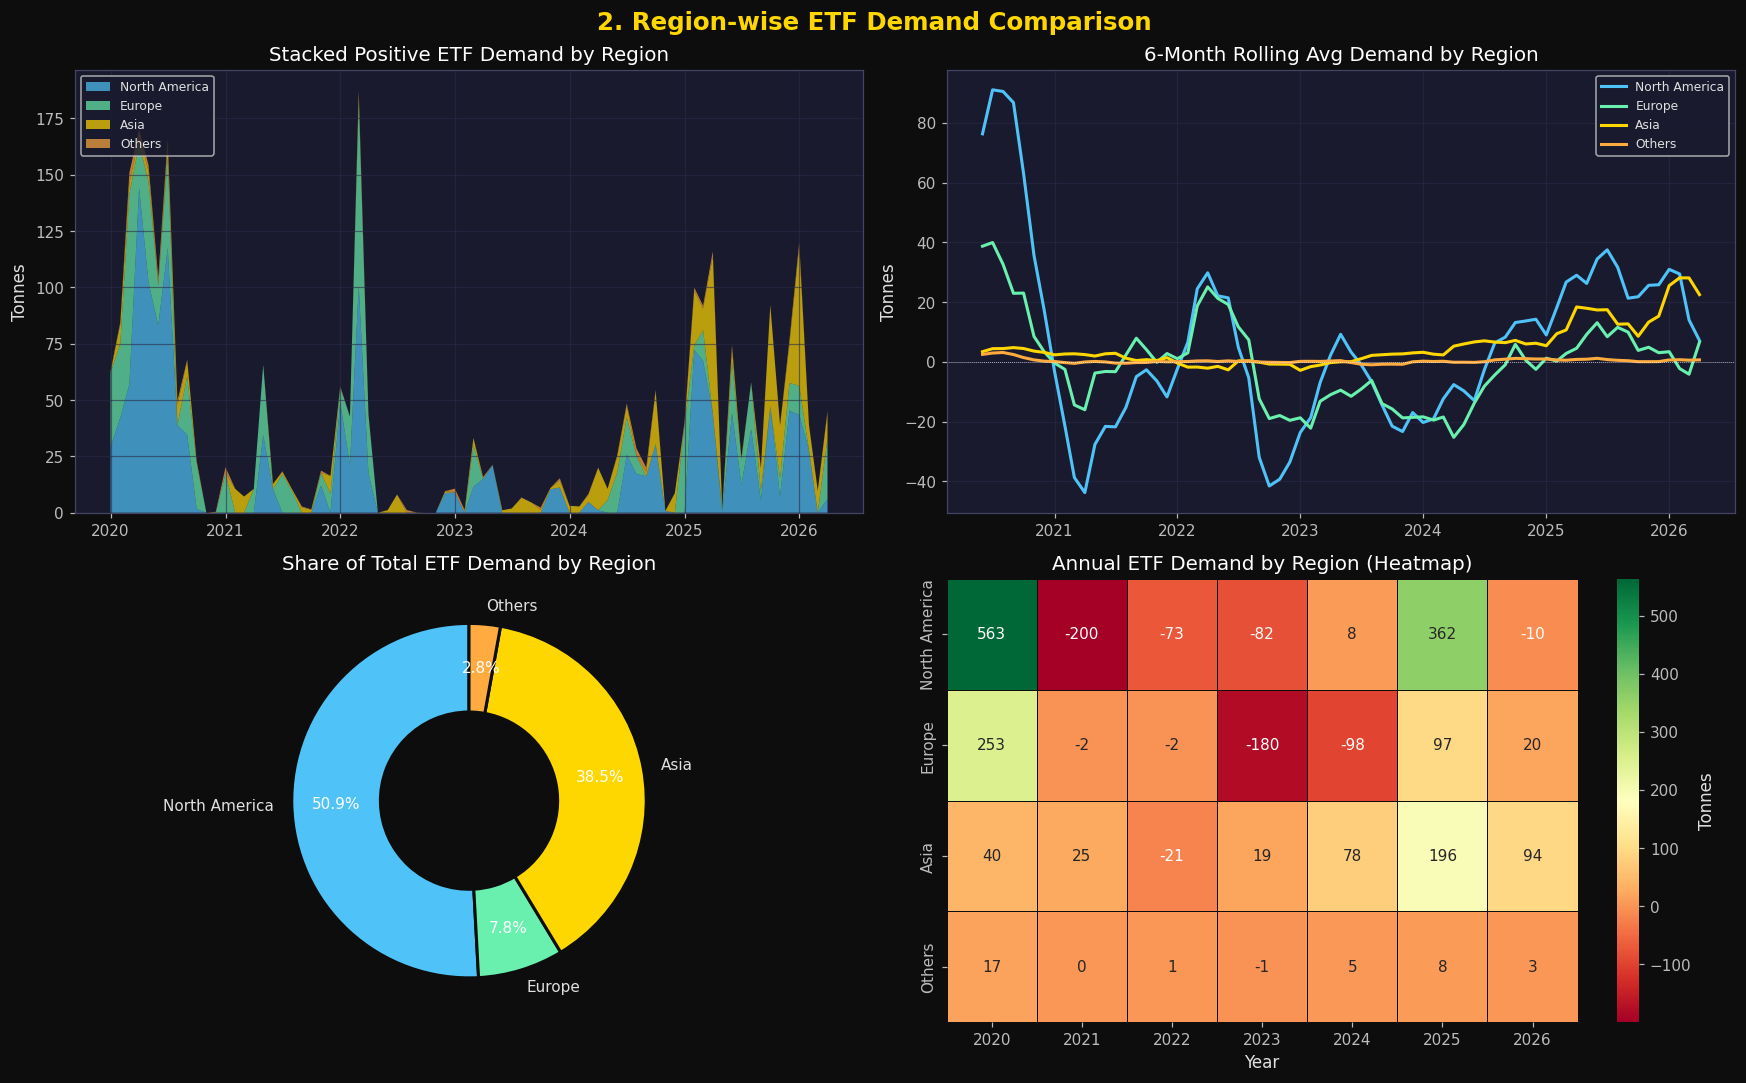


📌 REGIONAL INSIGHTS:
  • North America   :    568.6t (+50.9% of total ETF demand)
  • Europe          :     87.2t ( +7.8% of total ETF demand)
  • Asia            :    430.4t (+38.5% of total ETF demand)
  • Others          :     31.8t ( +2.8% of total ETF demand)


In [14]:
regions = ['North_America', 'Europe', 'Asia', 'Others']
r_colors = [BLUE, GREEN, GOLD, ORANGE]
r_labels = ['North America', 'Europe', 'Asia', 'Others']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('2. Region-wise ETF Demand Comparison', fontsize=16, fontweight='bold', color=GOLD, y=0.98)

# --- Row 1 Col 1: Stacked Area Chart ---
ax = axes[0, 0]
positives = df[regions].clip(lower=0)
ax.stackplot(df.Date, [positives[r] for r in regions], labels=r_labels, colors=r_colors, alpha=0.7)
ax.set_title('Stacked Positive ETF Demand by Region')
ax.set_ylabel('Tonnes')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True)

# --- Row 1 Col 2: Line Chart per region ---
ax = axes[0, 1]
for r, c, lbl in zip(regions, r_colors, r_labels):
    roll6 = df[r].rolling(6).mean()
    ax.plot(df.Date, roll6, color=c, linewidth=2, label=lbl)
ax.axhline(0, color='white', linewidth=0.5, linestyle=':')
ax.set_title('6-Month Rolling Avg Demand by Region')
ax.set_ylabel('Tonnes')
ax.legend(fontsize=8)
ax.grid(True)

# --- Row 2 Col 1: Donut chart total share ---
ax = axes[1, 0]
total_by_region = df[regions].sum().abs()
wedges, texts, autotexts = ax.pie(
    total_by_region, labels=r_labels, colors=r_colors, autopct='%1.1f%%',
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor='#0d0d0d', linewidth=2)
)
for at in autotexts: at.set_color('white'); at.set_fontsize(10)
for t in texts: t.set_color('#e0e0e0'); t.set_fontsize(10)
ax.set_title('Share of Total ETF Demand by Region')

# --- Row 2 Col 2: Annual breakdown heatmap ---
ax = axes[1, 1]
annual_region = df.groupby(df.Date.dt.year)[regions].sum()
annual_region.columns = r_labels
sns.heatmap(annual_region.T, annot=True, fmt='.0f', cmap='RdYlGn',
            ax=ax, linewidths=0.5, linecolor='#0d0d0d',
            cbar_kws={'label': 'Tonnes'})
ax.set_title('Annual ETF Demand by Region (Heatmap)')
ax.set_xlabel('Year')

plt.tight_layout()
plt.savefig('fig2_region_etf.png', bbox_inches='tight', dpi=120)
plt.show()

print("\n📌 REGIONAL INSIGHTS:")
for r, lbl in zip(regions, r_labels):
    tot = df[r].sum()
    pct = tot / df.ETF_Demand.sum() * 100
    print(f"  • {lbl:<16}: {tot:>8.1f}t ({pct:>+5.1f}% of total ETF demand)")

---
## 3. Gold Returns vs Total ETF Net Demand

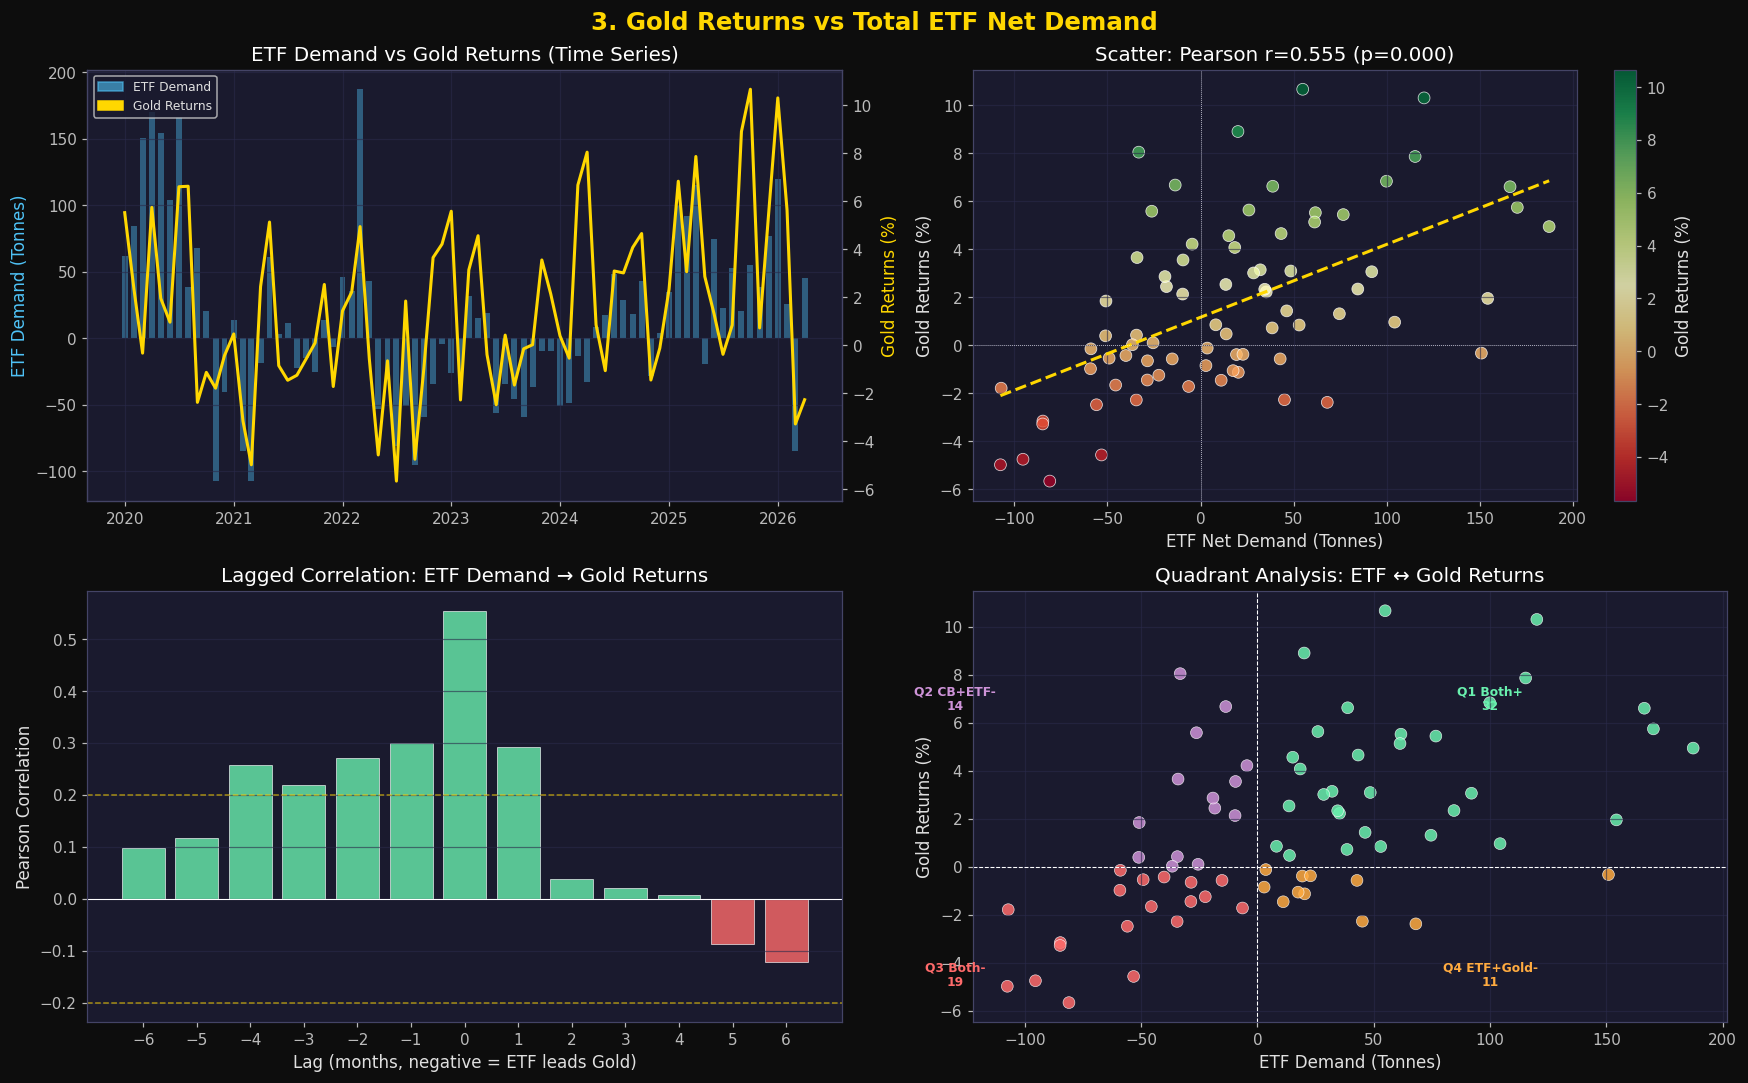


📌 KEY STATS — ETF Demand vs Gold Returns:
  • Pearson  r = 0.5546  (p-value = 0.0000) ✅ Significant
  • Spearman r = 0.5725  (p-value = 0.0000)
  • Strongest lagged correlation at lag=0 months: 0.5546


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('3. Gold Returns vs Total ETF Net Demand', fontsize=16, fontweight='bold', color=GOLD, y=0.98)

corr, pval = pearsonr(df.ETF_Demand, df.Gold_Returns)
sp_corr, sp_pval = spearmanr(df.ETF_Demand, df.Gold_Returns)

# --- Row 1 Col 1: Dual axis time series ---
ax1 = axes[0, 0]
ax2 = ax1.twinx()
ax1.bar(df.Date, df.ETF_Demand, color=BLUE, alpha=0.4, width=20, label='ETF Demand')
ax2.plot(df.Date, df.Gold_Returns, color=GOLD, linewidth=2, label='Gold Returns')
ax1.set_ylabel('ETF Demand (Tonnes)', color=BLUE)
ax2.set_ylabel('Gold Returns (%)', color=GOLD)
ax1.set_title('ETF Demand vs Gold Returns (Time Series)')
lines1 = mpatches.Patch(color=BLUE, alpha=0.6, label='ETF Demand')
lines2 = mpatches.Patch(color=GOLD, label='Gold Returns')
ax1.legend(handles=[lines1, lines2], fontsize=8, loc='upper left')
ax1.grid(True)

# --- Row 1 Col 2: Scatter ---
ax = axes[0, 1]
scatter = ax.scatter(df.ETF_Demand, df.Gold_Returns, c=df.Gold_Returns,
                     cmap='RdYlGn', s=60, alpha=0.8, edgecolors='white', linewidths=0.5)
m, b = np.polyfit(df.ETF_Demand, df.Gold_Returns, 1)
x_line = np.linspace(df.ETF_Demand.min(), df.ETF_Demand.max(), 100)
ax.plot(x_line, m * x_line + b, color=GOLD, linewidth=2, linestyle='--')
ax.set_xlabel('ETF Net Demand (Tonnes)')
ax.set_ylabel('Gold Returns (%)')
ax.set_title(f'Scatter: Pearson r={corr:.3f} (p={pval:.3f})')
plt.colorbar(scatter, ax=ax, label='Gold Returns (%)')
ax.axhline(0, color='white', linewidth=0.5, linestyle=':')
ax.axvline(0, color='white', linewidth=0.5, linestyle=':')
ax.grid(True)

# --- Row 2 Col 1: Lagged correlation ---
ax = axes[1, 0]
lags = range(-6, 7)
lag_corrs = [df['ETF_Demand'].shift(lag).corr(df['Gold_Returns']) for lag in lags]
colors_bar = [GREEN if c > 0 else RED for c in lag_corrs]
ax.bar(lags, lag_corrs, color=colors_bar, alpha=0.8, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='white', linewidth=0.7)
ax.axhline(0.2, color=GOLD, linewidth=1, linestyle='--', alpha=0.6)
ax.axhline(-0.2, color=GOLD, linewidth=1, linestyle='--', alpha=0.6)
ax.set_xlabel('Lag (months, negative = ETF leads Gold)')
ax.set_ylabel('Pearson Correlation')
ax.set_title('Lagged Correlation: ETF Demand → Gold Returns')
ax.set_xticks(list(lags))
ax.grid(True, axis='y')

# --- Row 2 Col 2: Quadrant Analysis ---
ax = axes[1, 1]
q_colors = [
    GREEN if (e > 0 and g > 0) else
    RED if (e < 0 and g < 0) else
    ORANGE if (e > 0 and g < 0) else PURPLE
    for e, g in zip(df.ETF_Demand, df.Gold_Returns)
]
ax.scatter(df.ETF_Demand, df.Gold_Returns, c=q_colors, s=60, alpha=0.85, edgecolors='white', linewidths=0.4)
ax.axhline(0, color='white', linewidth=0.7, linestyle='--')
ax.axvline(0, color='white', linewidth=0.7, linestyle='--')
ax.set_xlabel('ETF Demand (Tonnes)')
ax.set_ylabel('Gold Returns (%)')
ax.set_title('Quadrant Analysis: ETF ↔ Gold Returns')
q1 = sum(1 for e, g in zip(df.ETF_Demand, df.Gold_Returns) if e > 0 and g > 0)
q2 = sum(1 for e, g in zip(df.ETF_Demand, df.Gold_Returns) if e < 0 and g > 0)
q3 = sum(1 for e, g in zip(df.ETF_Demand, df.Gold_Returns) if e < 0 and g < 0)
q4 = sum(1 for e, g in zip(df.ETF_Demand, df.Gold_Returns) if e > 0 and g < 0)
for txt, xx, yy, col in [('Q1 Both+\n'+str(q1), 100, 7, GREEN), ('Q2 CB+ETF-\n'+str(q2), -130, 7, PURPLE),
                          ('Q3 Both-\n'+str(q3), -130, -4.5, RED), ('Q4 ETF+Gold-\n'+str(q4), 100, -4.5, ORANGE)]:
    ax.text(xx, yy, txt, ha='center', va='center', color=col, fontsize=8, fontweight='bold')
ax.grid(True)

plt.tight_layout()
plt.savefig('fig3_etf_vs_returns.png', bbox_inches='tight', dpi=120)
plt.show()

print(f"\n📌 KEY STATS — ETF Demand vs Gold Returns:")
print(f"  • Pearson  r = {corr:.4f}  (p-value = {pval:.4f}) {'✅ Significant' if pval < 0.05 else '❌ Not significant'}")
print(f"  • Spearman r = {sp_corr:.4f}  (p-value = {sp_pval:.4f})")
best_lag = min(lags, key=lambda l: -abs(df.ETF_Demand.shift(l).corr(df.Gold_Returns)))
print(f"  • Strongest lagged correlation at lag={best_lag} months: {df.ETF_Demand.shift(best_lag).corr(df.Gold_Returns):.4f}")

---
## 4. Gold Returns vs Central Bank Net Demand

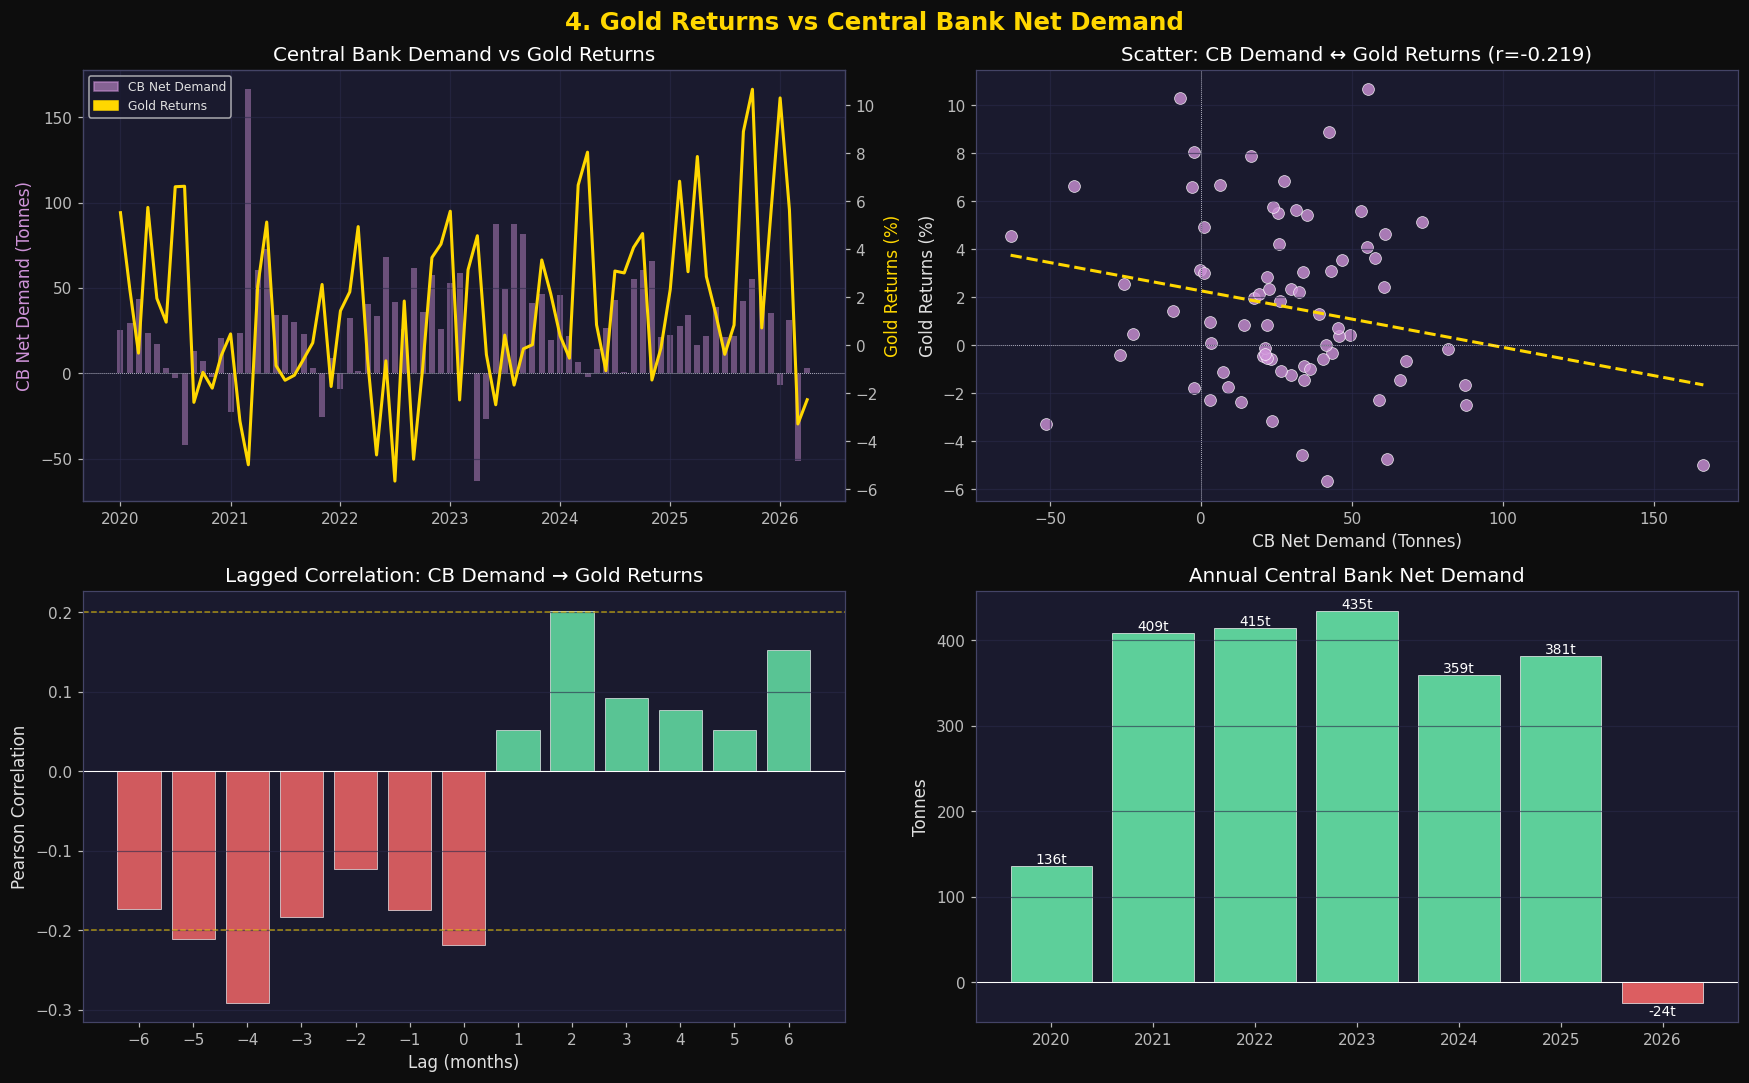


📌 KEY STATS — Central Bank vs Gold Returns:
  • Pearson r  = -0.2191  (p-value = 0.0572) ❌ Not significant at 5%
  • Total CB demand over period: 2110.5 tonnes
  • Strongest lagged correlation at lag=-4: -0.2912


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('4. Gold Returns vs Central Bank Net Demand', fontsize=16, fontweight='bold', color=GOLD, y=0.98)

corr_cb, pval_cb = pearsonr(df.CB_Demand, df.Gold_Returns)

# --- Row 1 Col 1: Dual axis ---
ax1 = axes[0, 0]
ax2 = ax1.twinx()
ax1.bar(df.Date, df.CB_Demand, color=PURPLE, alpha=0.45, width=20, label='CB Demand')
ax2.plot(df.Date, df.Gold_Returns, color=GOLD, linewidth=2, label='Gold Returns')
ax1.axhline(0, color='white', linewidth=0.5, linestyle=':')
ax1.set_ylabel('CB Net Demand (Tonnes)', color=PURPLE)
ax2.set_ylabel('Gold Returns (%)', color=GOLD)
ax1.set_title('Central Bank Demand vs Gold Returns')
h1 = mpatches.Patch(color=PURPLE, alpha=0.6, label='CB Net Demand')
h2 = mpatches.Patch(color=GOLD, label='Gold Returns')
ax1.legend(handles=[h1, h2], fontsize=8, loc='upper left')
ax1.grid(True)

# --- Row 1 Col 2: Scatter with regression ---
ax = axes[0, 1]
ax.scatter(df.CB_Demand, df.Gold_Returns, c=PURPLE, s=60, alpha=0.8, edgecolors='white', linewidths=0.5)
m2, b2 = np.polyfit(df.CB_Demand, df.Gold_Returns, 1)
xr = np.linspace(df.CB_Demand.min(), df.CB_Demand.max(), 100)
ax.plot(xr, m2 * xr + b2, color=GOLD, linewidth=2, linestyle='--')
ax.set_xlabel('CB Net Demand (Tonnes)')
ax.set_ylabel('Gold Returns (%)')
ax.set_title(f'Scatter: CB Demand ↔ Gold Returns (r={corr_cb:.3f})')
ax.axhline(0, color='white', linewidth=0.5, linestyle=':')
ax.axvline(0, color='white', linewidth=0.5, linestyle=':')
ax.grid(True)

# --- Row 2 Col 1: Lagged correlation CB ---
ax = axes[1, 0]
lag_corrs_cb = [df['CB_Demand'].shift(lag).corr(df['Gold_Returns']) for lag in lags]
cb_colors = [GREEN if c > 0 else RED for c in lag_corrs_cb]
ax.bar(lags, lag_corrs_cb, color=cb_colors, alpha=0.8, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='white', linewidth=0.7)
ax.axhline(0.2, color=GOLD, linewidth=1, linestyle='--', alpha=0.6)
ax.axhline(-0.2, color=GOLD, linewidth=1, linestyle='--', alpha=0.6)
ax.set_xlabel('Lag (months)')
ax.set_ylabel('Pearson Correlation')
ax.set_title('Lagged Correlation: CB Demand → Gold Returns')
ax.set_xticks(list(lags))
ax.grid(True, axis='y')

# --- Row 2 Col 2: CB demand annual bar ---
ax = axes[1, 1]
cb_annual = df.groupby(df.Date.dt.year)['CB_Demand'].sum()
c_colors = [GREEN if v >= 0 else RED for v in cb_annual]
bars = ax.bar(cb_annual.index.astype(str), cb_annual.values, color=c_colors, alpha=0.85,
              edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, cb_annual.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (3 if val >= 0 else -15),
            f'{val:.0f}t', ha='center', fontsize=9, color='white')
ax.set_title('Annual Central Bank Net Demand')
ax.set_ylabel('Tonnes')
ax.axhline(0, color='white', linewidth=0.7)
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('fig4_cb_vs_returns.png', bbox_inches='tight', dpi=120)
plt.show()

print(f"\n📌 KEY STATS — Central Bank vs Gold Returns:")
print(f"  • Pearson r  = {corr_cb:.4f}  (p-value = {pval_cb:.4f}) {'✅ Significant' if pval_cb < 0.05 else '❌ Not significant at 5%'}")
print(f"  • Total CB demand over period: {df.CB_Demand.sum():.1f} tonnes")
best_cb_lag = min(lags, key=lambda l: -abs(df.CB_Demand.shift(l).corr(df.Gold_Returns)))
print(f"  • Strongest lagged correlation at lag={best_cb_lag}: {df.CB_Demand.shift(best_cb_lag).corr(df.Gold_Returns):.4f}")

---
## 5. ETF Demand vs Central Bank Demand Comparison

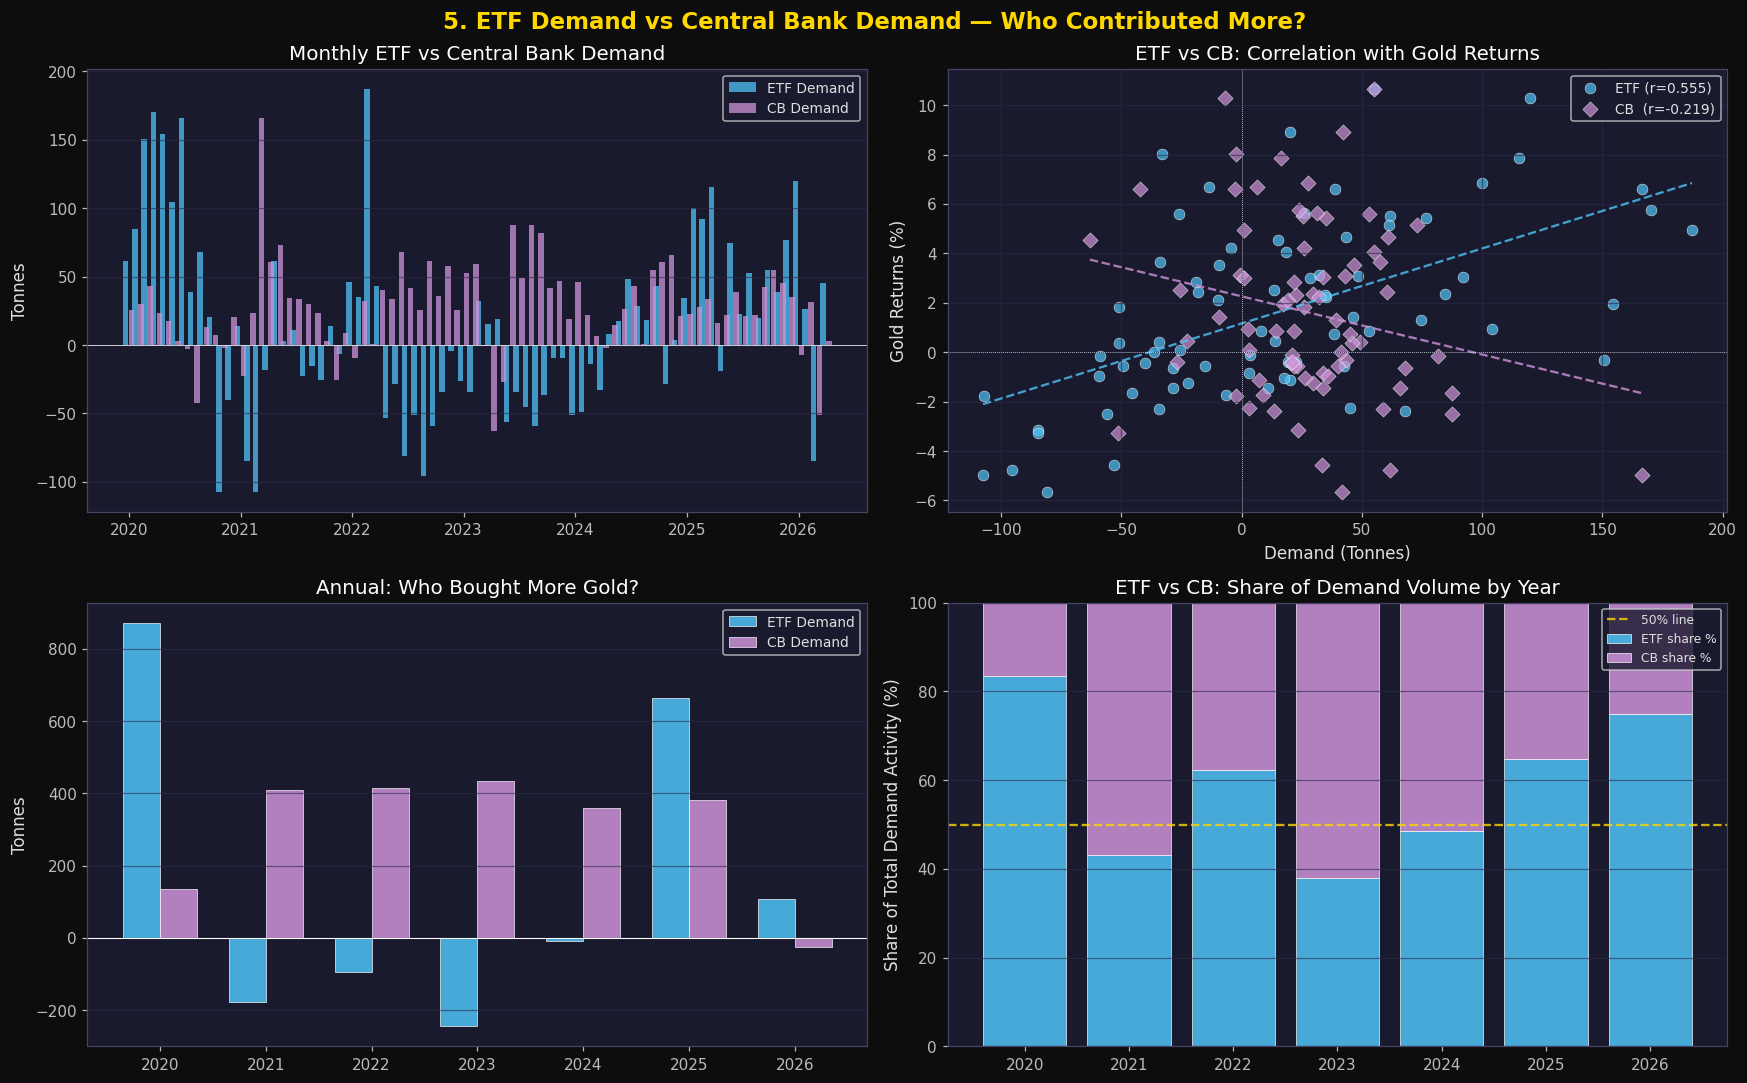


📌 WHO CONTRIBUTED MORE — VERDICT:
  2020: ETF=   872.2t | CB=   135.9t → Dominant: ETFs
  2021: ETF=  -177.3t | CB=   408.7t → Dominant: Central Banks
  2022: ETF=   -94.9t | CB=   414.8t → Dominant: Central Banks
  2023: ETF=  -244.5t | CB=   434.7t → Dominant: Central Banks
  2024: ETF=    -7.5t | CB=   359.1t → Dominant: Central Banks
  2025: ETF=   663.2t | CB=   381.4t → Dominant: ETFs
  2026: ETF=   106.4t | CB=   -24.1t → Dominant: ETFs

  ▶ OVERALL: ETF=1117.6t | CB=2110.5t → Dominant: Central Banks


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('5. ETF Demand vs Central Bank Demand — Who Contributed More?',
             fontsize=15, fontweight='bold', color=GOLD, y=0.98)

# --- Row 1 Col 1: Side by side bars ---
ax = axes[0, 0]
x = np.arange(len(df))
w = 0.45
ax.bar(df.Date - pd.Timedelta(days=10), df.ETF_Demand, width=18, color=BLUE, alpha=0.75, label='ETF Demand')
ax.bar(df.Date + pd.Timedelta(days=10), df.CB_Demand, width=18, color=PURPLE, alpha=0.75, label='CB Demand')
ax.axhline(0, color='white', linewidth=0.5)
ax.set_title('Monthly ETF vs Central Bank Demand')
ax.set_ylabel('Tonnes')
ax.legend(fontsize=9)
ax.grid(True, axis='y')

# --- Row 1 Col 2: Contribution to Gold Returns comparison ---
ax = axes[0, 1]
ax.scatter(df.ETF_Demand, df.Gold_Returns, c=BLUE, s=50, alpha=0.7, label=f'ETF (r={corr:.3f})', edgecolors='white', linewidths=0.4)
ax.scatter(df.CB_Demand, df.Gold_Returns, c=PURPLE, s=50, alpha=0.7, label=f'CB  (r={corr_cb:.3f})', marker='D', edgecolors='white', linewidths=0.4)
for col, vals in [(BLUE, df.ETF_Demand), (PURPLE, df.CB_Demand)]:
    mm, bb = np.polyfit(vals, df.Gold_Returns, 1)
    xrr = np.linspace(vals.min(), vals.max(), 100)
    ax.plot(xrr, mm * xrr + bb, color=col, linewidth=1.5, linestyle='--', alpha=0.8)
ax.axhline(0, color='white', linewidth=0.5, linestyle=':')
ax.axvline(0, color='white', linewidth=0.5, linestyle=':')
ax.set_xlabel('Demand (Tonnes)')
ax.set_ylabel('Gold Returns (%)')
ax.set_title('ETF vs CB: Correlation with Gold Returns')
ax.legend(fontsize=9)
ax.grid(True)

# --- Row 2 Col 1: Annual dominance: who bought more ---
ax = axes[1, 0]
annual = df.groupby(df.Date.dt.year)[['ETF_Demand','CB_Demand']].sum()
x_pos = np.arange(len(annual))
w = 0.35
b1 = ax.bar(x_pos - w/2, annual.ETF_Demand, w, color=BLUE, alpha=0.85, label='ETF Demand', edgecolor='white', linewidth=0.5)
b2 = ax.bar(x_pos + w/2, annual.CB_Demand, w, color=PURPLE, alpha=0.85, label='CB Demand', edgecolor='white', linewidth=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(annual.index.astype(str))
ax.set_title('Annual: Who Bought More Gold?')
ax.set_ylabel('Tonnes')
ax.axhline(0, color='white', linewidth=0.7)
ax.legend(fontsize=9)
ax.grid(True, axis='y')

# --- Row 2 Col 2: Radar / contribution pie per year ---
ax = axes[1, 1]
annual_abs = df.groupby(df.Date.dt.year)[['ETF_Demand','CB_Demand']].apply(lambda x: x.abs().sum())
etf_share = annual_abs.ETF_Demand / (annual_abs.ETF_Demand + annual_abs.CB_Demand) * 100
cb_share  = annual_abs.CB_Demand  / (annual_abs.ETF_Demand + annual_abs.CB_Demand) * 100
x_pos2 = np.arange(len(annual_abs))
ax.bar(x_pos2, etf_share, color=BLUE, alpha=0.85, label='ETF share %', edgecolor='white', linewidth=0.5)
ax.bar(x_pos2, cb_share, bottom=etf_share, color=PURPLE, alpha=0.85, label='CB share %', edgecolor='white', linewidth=0.5)
ax.set_xticks(x_pos2)
ax.set_xticklabels(annual_abs.index.astype(str))
ax.axhline(50, color=GOLD, linewidth=1.5, linestyle='--', alpha=0.8, label='50% line')
ax.set_ylabel('Share of Total Demand Activity (%)')
ax.set_title('ETF vs CB: Share of Demand Volume by Year')
ax.legend(fontsize=8)
ax.set_ylim(0, 100)
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('fig5_etf_vs_cb.png', bbox_inches='tight', dpi=120)
plt.show()

print("\n📌 WHO CONTRIBUTED MORE — VERDICT:")
for yr in annual.index:
    e, c = annual.loc[yr, 'ETF_Demand'], annual.loc[yr, 'CB_Demand']
    winner = 'ETFs' if abs(e) > abs(c) else 'Central Banks'
    print(f"  {yr}: ETF={e:>8.1f}t | CB={c:>8.1f}t → Dominant: {winner}")
total_etf = df.ETF_Demand.sum()
total_cb  = df.CB_Demand.sum()
print(f"\n  ▶ OVERALL: ETF={total_etf:.1f}t | CB={total_cb:.1f}t → Dominant: {'ETFs' if abs(total_etf) > abs(total_cb) else 'Central Banks'}")

---
## 6. Total Net Demand vs Gold Returns

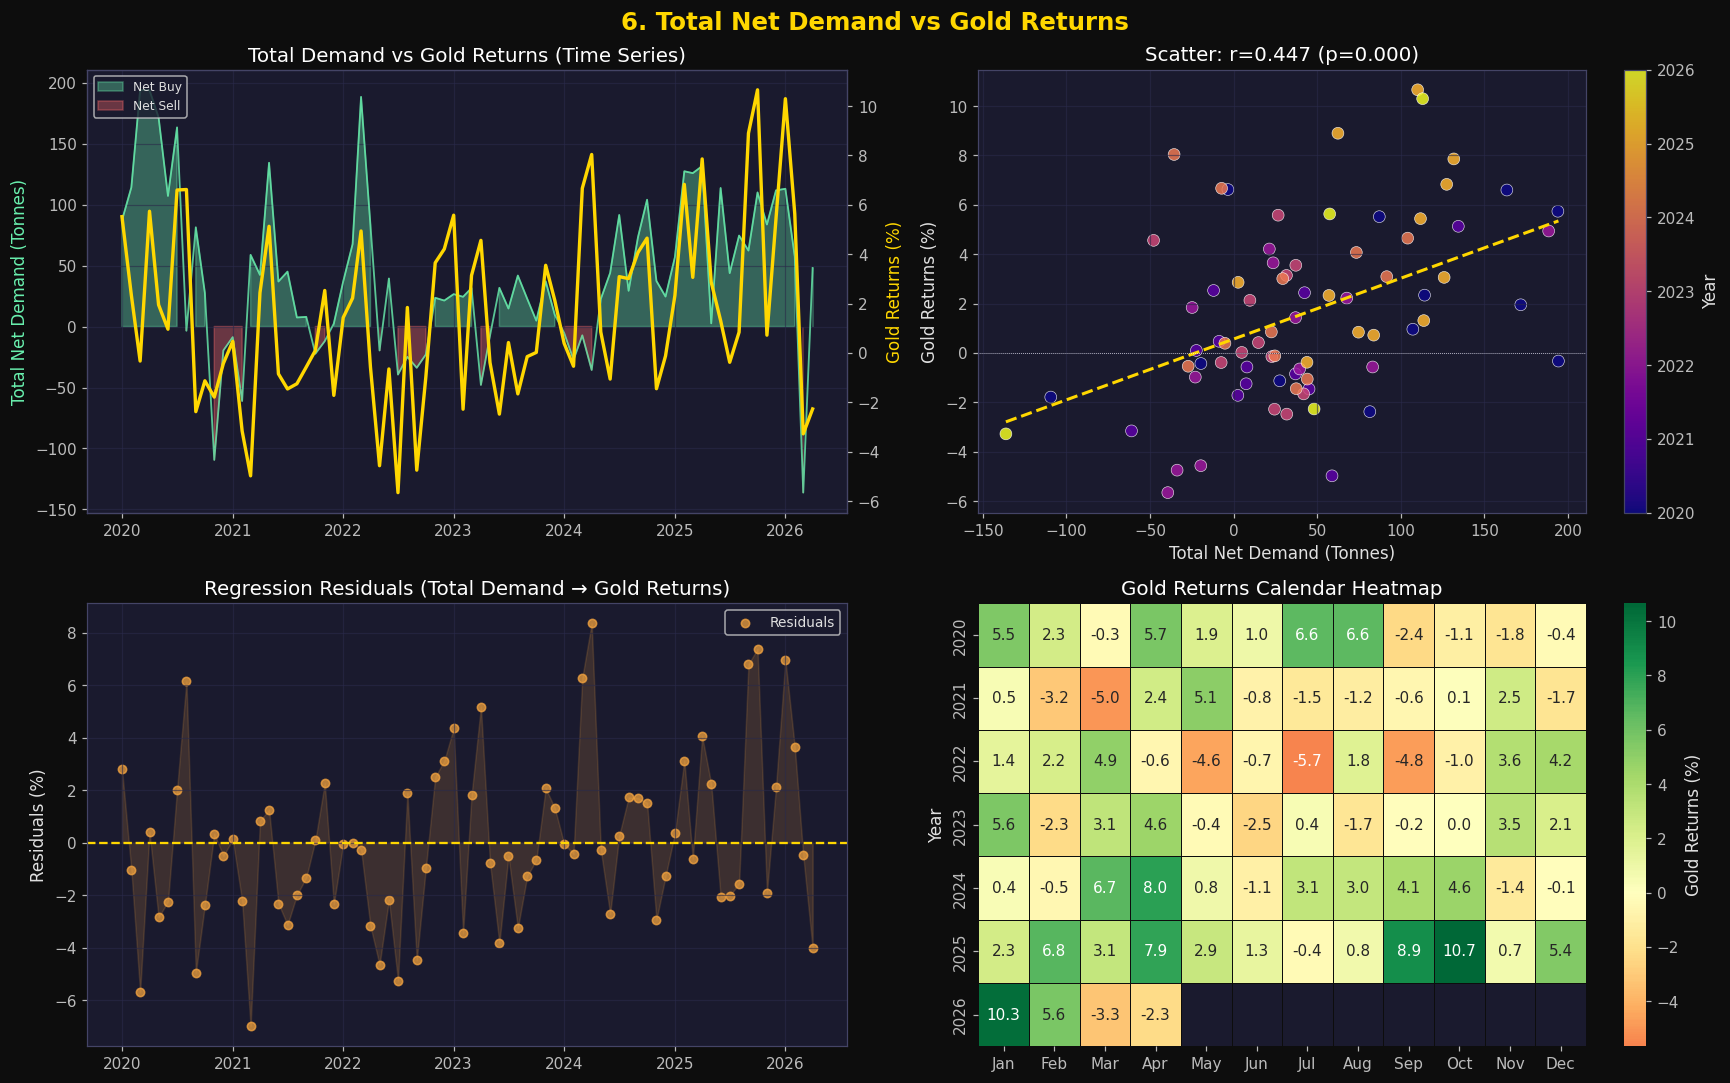


📌 Total Net Demand → Gold Returns:
  • Pearson r = 0.4466 (p = 0.0001) ✅ Significant
  • R² = 0.1994  →  Total demand explains 19.9% of Gold Return variance


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('6. Total Net Demand vs Gold Returns', fontsize=16, fontweight='bold', color=GOLD, y=0.98)

corr_tot, pval_tot = pearsonr(df.Total_Demand, df.Gold_Returns)

# --- Row 1 Col 1: Time series ---
ax1 = axes[0, 0]
ax2 = ax1.twinx()
ax1.fill_between(df.Date, df.Total_Demand, where=df.Total_Demand >= 0, color=GREEN, alpha=0.35, label='Net Buy')
ax1.fill_between(df.Date, df.Total_Demand, where=df.Total_Demand < 0, color=RED, alpha=0.35, label='Net Sell')
ax1.plot(df.Date, df.Total_Demand, color=GREEN, linewidth=1.2, alpha=0.8)
ax2.plot(df.Date, df.Gold_Returns, color=GOLD, linewidth=2.2)
ax1.set_ylabel('Total Net Demand (Tonnes)', color=GREEN)
ax2.set_ylabel('Gold Returns (%)', color=GOLD)
ax1.set_title('Total Demand vs Gold Returns (Time Series)')
ax1.legend(fontsize=8, loc='upper left')
ax1.grid(True)

# --- Row 1 Col 2: Scatter ---
ax = axes[0, 1]
sc = ax.scatter(df.Total_Demand, df.Gold_Returns, c=df.Date.dt.year,
                cmap='plasma', s=60, alpha=0.85, edgecolors='white', linewidths=0.4)
m3, b3 = np.polyfit(df.Total_Demand, df.Gold_Returns, 1)
xr3 = np.linspace(df.Total_Demand.min(), df.Total_Demand.max(), 100)
ax.plot(xr3, m3*xr3+b3, color=GOLD, linewidth=2, linestyle='--')
plt.colorbar(sc, ax=ax, label='Year')
ax.set_xlabel('Total Net Demand (Tonnes)')
ax.set_ylabel('Gold Returns (%)')
ax.set_title(f'Scatter: r={corr_tot:.3f} (p={pval_tot:.3f})')
ax.axhline(0, color='white', linewidth=0.5, linestyle=':')
ax.grid(True)

# --- Row 2 Col 1: Regression decomposition ---
ax = axes[1, 0]
X = add_constant(df.Total_Demand)
model = OLS(df.Gold_Returns, X).fit()
fitted = model.fittedvalues
residuals = model.resid
ax.scatter(df.Date, residuals, color=ORANGE, s=30, alpha=0.7, label='Residuals')
ax.axhline(0, color=GOLD, linewidth=1.5, linestyle='--')
ax.fill_between(df.Date, residuals, color=ORANGE, alpha=0.15)
ax.set_title('Regression Residuals (Total Demand → Gold Returns)')
ax.set_ylabel('Residuals (%)')
ax.legend(fontsize=9)
ax.grid(True)

# --- Row 2 Col 2: Monthly Returns Heatmap ---
ax = axes[1, 1]
df['Year'] = df.Date.dt.year
df['Month'] = df.Date.dt.month
hmap = df.pivot_table(index='Year', columns='Month', values='Gold_Returns')
hmap.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
sns.heatmap(hmap, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax,
            linewidths=0.5, linecolor='#0d0d0d', center=0,
            cbar_kws={'label': 'Gold Returns (%)'})
ax.set_title('Gold Returns Calendar Heatmap')
ax.set_xlabel('')

plt.tight_layout()
plt.savefig('fig6_total_demand_returns.png', bbox_inches='tight', dpi=120)
plt.show()

print(f"\n📌 Total Net Demand → Gold Returns:")
print(f"  • Pearson r = {corr_tot:.4f} (p = {pval_tot:.4f}) {'✅ Significant' if pval_tot < 0.05 else '❌ Not significant'}")
print(f"  • R² = {model.rsquared:.4f}  →  Total demand explains {model.rsquared*100:.1f}% of Gold Return variance")

---
## 7. USD Index Impact on Gold Returns

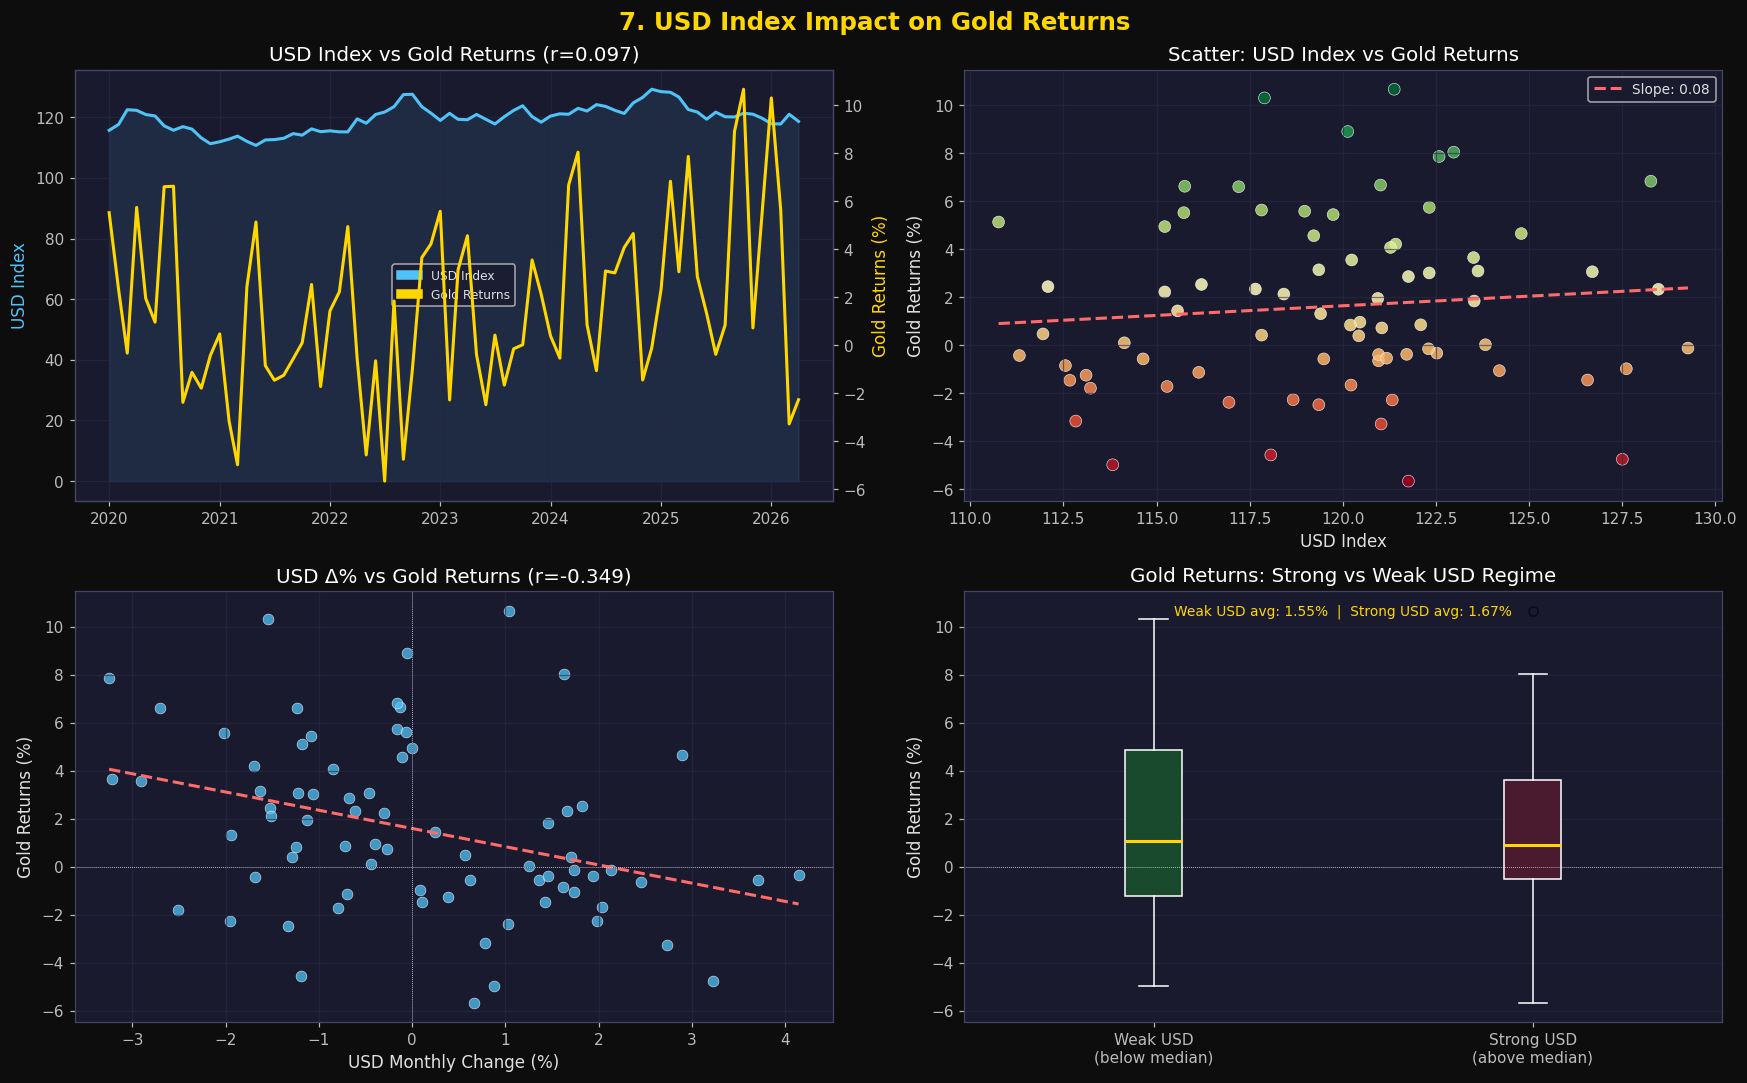


📌 USD INDEX INSIGHTS:
  • Pearson r (Level) = 0.0969  ❌ (p=0.4050)
  • Pearson r (Change) = -0.3491  (inverse relationship: USD↑ → Gold↓)
  • Avg Gold Return in Weak USD months  : 1.55%
  • Avg Gold Return in Strong USD months: 1.67%


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('7. USD Index Impact on Gold Returns', fontsize=16, fontweight='bold', color=GOLD, y=0.98)

corr_usd, pval_usd = pearsonr(df.USD_Index, df.Gold_Returns)
df['USD_Change'] = df.USD_Index.pct_change() * 100
corr_usd_ch, _ = pearsonr(df.USD_Change.dropna(), df.Gold_Returns.iloc[1:])

# --- Row 1 Col 1: Dual axis USD vs Gold ---
ax1 = axes[0, 0]
ax2 = ax1.twinx()
ax1.plot(df.Date, df.USD_Index, color=BLUE, linewidth=2, label='USD Index')
ax2.plot(df.Date, df.Gold_Returns, color=GOLD, linewidth=2, label='Gold Returns')
ax1.fill_between(df.Date, df.USD_Index, alpha=0.1, color=BLUE)
ax1.set_ylabel('USD Index', color=BLUE)
ax2.set_ylabel('Gold Returns (%)', color=GOLD)
ax1.set_title(f'USD Index vs Gold Returns (r={corr_usd:.3f})')
h1 = mpatches.Patch(color=BLUE, label='USD Index')
h2 = mpatches.Patch(color=GOLD, label='Gold Returns')
ax1.legend(handles=[h1, h2], fontsize=8)
ax1.grid(True)

# --- Row 1 Col 2: Scatter USD vs Gold ---
ax = axes[0, 1]
ax.scatter(df.USD_Index, df.Gold_Returns, c=df.Gold_Returns, cmap='RdYlGn',
           s=60, alpha=0.85, edgecolors='white', linewidths=0.4)
m4, b4 = np.polyfit(df.USD_Index, df.Gold_Returns, 1)
xr4 = np.linspace(df.USD_Index.min(), df.USD_Index.max(), 100)
ax.plot(xr4, m4*xr4+b4, color=RED, linewidth=2, linestyle='--', label=f'Slope: {m4:.2f}')
ax.set_xlabel('USD Index')
ax.set_ylabel('Gold Returns (%)')
ax.set_title('Scatter: USD Index vs Gold Returns')
ax.legend(fontsize=9)
ax.grid(True)

# --- Row 2 Col 1: USD change vs Gold Returns ---
ax = axes[1, 0]
d = df.dropna(subset=['USD_Change'])
ax.scatter(d.USD_Change, d.Gold_Returns, c=BLUE, s=50, alpha=0.75, edgecolors='white', linewidths=0.4)
m5, b5 = np.polyfit(d.USD_Change, d.Gold_Returns, 1)
xr5 = np.linspace(d.USD_Change.min(), d.USD_Change.max(), 100)
ax.plot(xr5, m5*xr5+b5, color=RED, linewidth=2, linestyle='--')
ax.axhline(0, color='white', linewidth=0.5, linestyle=':')
ax.axvline(0, color='white', linewidth=0.5, linestyle=':')
ax.set_xlabel('USD Monthly Change (%)')
ax.set_ylabel('Gold Returns (%)')
ax.set_title(f'USD Δ% vs Gold Returns (r={corr_usd_ch:.3f})')
ax.grid(True)

# --- Row 2 Col 2: USD regime analysis ---
ax = axes[1, 1]
usd_median = df.USD_Index.median()
strong_usd = df[df.USD_Index >= usd_median]['Gold_Returns']
weak_usd   = df[df.USD_Index <  usd_median]['Gold_Returns']
bp = ax.boxplot([weak_usd, strong_usd], patch_artist=True,
                labels=['Weak USD\n(below median)', 'Strong USD\n(above median)'],
                boxprops=dict(facecolor='#1a1a2e', color='white'),
                medianprops=dict(color=GOLD, linewidth=2),
                whiskerprops=dict(color='white'),
                capprops=dict(color='white'),
                flierprops=dict(marker='o', color=ORANGE, alpha=0.6))
bp['boxes'][0].set_facecolor('#1a4a2e')
bp['boxes'][1].set_facecolor('#4a1a2e')
ax.axhline(0, color='white', linewidth=0.5, linestyle=':')
ax.set_title(f'Gold Returns: Strong vs Weak USD Regime')
ax.set_ylabel('Gold Returns (%)')
ax.text(0.5, 0.97, f'Weak USD avg: {weak_usd.mean():.2f}%  |  Strong USD avg: {strong_usd.mean():.2f}%',
        transform=ax.transAxes, ha='center', va='top', fontsize=9, color=GOLD)
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('fig7_usd_returns.png', bbox_inches='tight', dpi=120)
plt.show()

print(f"\n📌 USD INDEX INSIGHTS:")
print(f"  • Pearson r (Level) = {corr_usd:.4f}  {'✅' if pval_usd<0.05 else '❌'} (p={pval_usd:.4f})")
print(f"  • Pearson r (Change) = {corr_usd_ch:.4f}  (inverse relationship: USD↑ → Gold↓)")
print(f"  • Avg Gold Return in Weak USD months  : {weak_usd.mean():.2f}%")
print(f"  • Avg Gold Return in Strong USD months: {strong_usd.mean():.2f}%")

---
## 8. Interest Rate Impact on Gold Returns

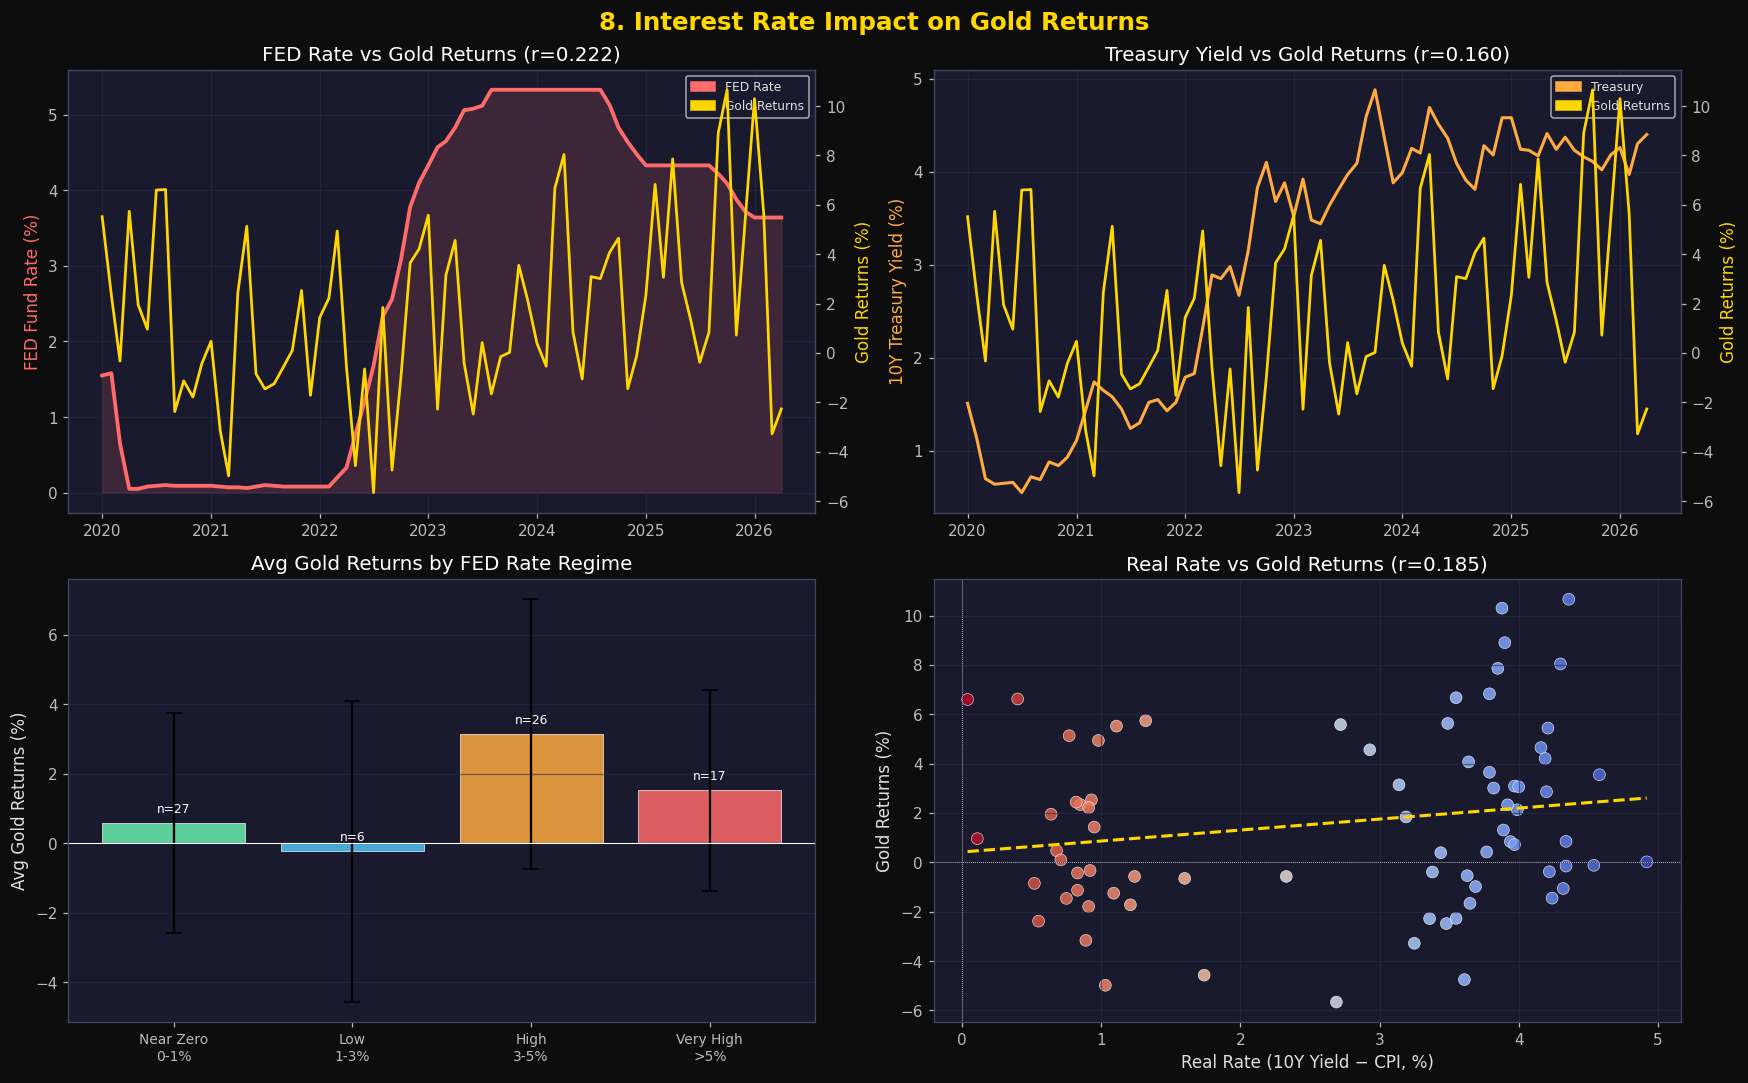


📌 INTEREST RATE INSIGHTS:
  • FED Rate vs Gold Returns  : r = 0.2217  (p = 0.0543)
  • Treasury Yield vs Gold    : r = 0.1599  (p = 0.1677)
  • Real Rate vs Gold Returns : r = 0.1851  (p = 0.1095)
  → Gold tends to perform worse when real rates are negative/low


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('8. Interest Rate Impact on Gold Returns', fontsize=16, fontweight='bold', color=GOLD, y=0.98)

corr_fed, pval_fed = pearsonr(df.FED_Rate, df.Gold_Returns)
corr_tsy, pval_tsy = pearsonr(df.Treasury_Yield, df.Gold_Returns)

# --- Row 1 Col 1: FED Rate vs Gold Returns time series ---
ax1 = axes[0, 0]
ax2 = ax1.twinx()
ax1.plot(df.Date, df.FED_Rate, color=RED, linewidth=2.5, label='FED Fund Rate')
ax1.fill_between(df.Date, df.FED_Rate, color=RED, alpha=0.15)
ax2.plot(df.Date, df.Gold_Returns, color=GOLD, linewidth=1.8, label='Gold Returns')
ax1.set_ylabel('FED Fund Rate (%)', color=RED)
ax2.set_ylabel('Gold Returns (%)', color=GOLD)
ax1.set_title(f'FED Rate vs Gold Returns (r={corr_fed:.3f})')
ax1.legend(handles=[mpatches.Patch(color=RED, label='FED Rate'),
                    mpatches.Patch(color=GOLD, label='Gold Returns')], fontsize=8)
ax1.grid(True)

# --- Row 1 Col 2: Treasury Yield vs Gold Returns ---
ax1 = axes[0, 1]
ax2 = ax1.twinx()
ax1.plot(df.Date, df.Treasury_Yield, color=ORANGE, linewidth=2, label='10Y Treasury')
ax2.plot(df.Date, df.Gold_Returns, color=GOLD, linewidth=1.8, label='Gold Returns')
ax1.set_ylabel('10Y Treasury Yield (%)', color=ORANGE)
ax2.set_ylabel('Gold Returns (%)', color=GOLD)
ax1.set_title(f'Treasury Yield vs Gold Returns (r={corr_tsy:.3f})')
ax1.legend(handles=[mpatches.Patch(color=ORANGE, label='Treasury'),
                    mpatches.Patch(color=GOLD, label='Gold Returns')], fontsize=8)
ax1.grid(True)

# --- Row 2 Col 1: FED Rate regimes ---
ax = axes[1, 0]
fed_breaks = pd.cut(df.FED_Rate, bins=[0, 1, 3, 5, 10],
                    labels=['Near Zero\n0-1%', 'Low\n1-3%', 'High\n3-5%', 'Very High\n>5%'])
regime_means = df.groupby(fed_breaks, observed=False)['Gold_Returns'].mean()
regime_counts = df.groupby(fed_breaks, observed=False)['Gold_Returns'].count()
regime_stds = df.groupby(fed_breaks, observed=False)['Gold_Returns'].std()
colors_rate = [GREEN, BLUE, ORANGE, RED]
bars_r = ax.bar(range(len(regime_means)), regime_means.values,
                color=[c for c, v in zip(colors_rate, regime_means.values)],
                alpha=0.85, edgecolor='white', linewidth=0.5,
                yerr=regime_stds.values, capsize=5, error_kw={'color': 'white', 'linewidth': 1.5})
ax.set_xticks(range(len(regime_means)))
ax.set_xticklabels(regime_means.index, fontsize=9)
ax.axhline(0, color='white', linewidth=0.7)
for i, (v, n) in enumerate(zip(regime_means.values, regime_counts.values)):
    ax.text(i, (v or 0) + 0.3 if not np.isnan(v) else 0.3, f'n={n}', ha='center', fontsize=8, color='white')
ax.set_title('Avg Gold Returns by FED Rate Regime')
ax.set_ylabel('Avg Gold Returns (%)')
ax.grid(True, axis='y')

# --- Row 2 Col 2: Real rate proxy ---
ax = axes[1, 1]
df['Real_Rate'] = df.Treasury_Yield - df.CPI
corr_real, pval_real = pearsonr(df.Real_Rate, df.Gold_Returns)
ax.scatter(df.Real_Rate, df.Gold_Returns, c=df.Real_Rate, cmap='coolwarm_r',
           s=60, alpha=0.85, edgecolors='white', linewidths=0.4)
mr, br = np.polyfit(df.Real_Rate, df.Gold_Returns, 1)
xrr2 = np.linspace(df.Real_Rate.min(), df.Real_Rate.max(), 100)
ax.plot(xrr2, mr*xrr2+br, color=GOLD, linewidth=2, linestyle='--')
ax.axhline(0, color='white', linewidth=0.5, linestyle=':')
ax.axvline(0, color='white', linewidth=0.5, linestyle=':')
ax.set_xlabel('Real Rate (10Y Yield − CPI, %)')
ax.set_ylabel('Gold Returns (%)')
ax.set_title(f'Real Rate vs Gold Returns (r={corr_real:.3f})')
ax.grid(True)

plt.tight_layout()
plt.savefig('fig8_rates_returns.png', bbox_inches='tight', dpi=120)
plt.show()

print(f"\n📌 INTEREST RATE INSIGHTS:")
print(f"  • FED Rate vs Gold Returns  : r = {corr_fed:.4f}  (p = {pval_fed:.4f})")
print(f"  • Treasury Yield vs Gold    : r = {corr_tsy:.4f}  (p = {pval_tsy:.4f})")
print(f"  • Real Rate vs Gold Returns : r = {corr_real:.4f}  (p = {pval_real:.4f})")
print(f"  → Gold tends to perform {'better' if corr_real < 0 else 'worse'} when real rates are negative/low")

---
## 9. Inflation and Oil Price Effect on Gold Returns

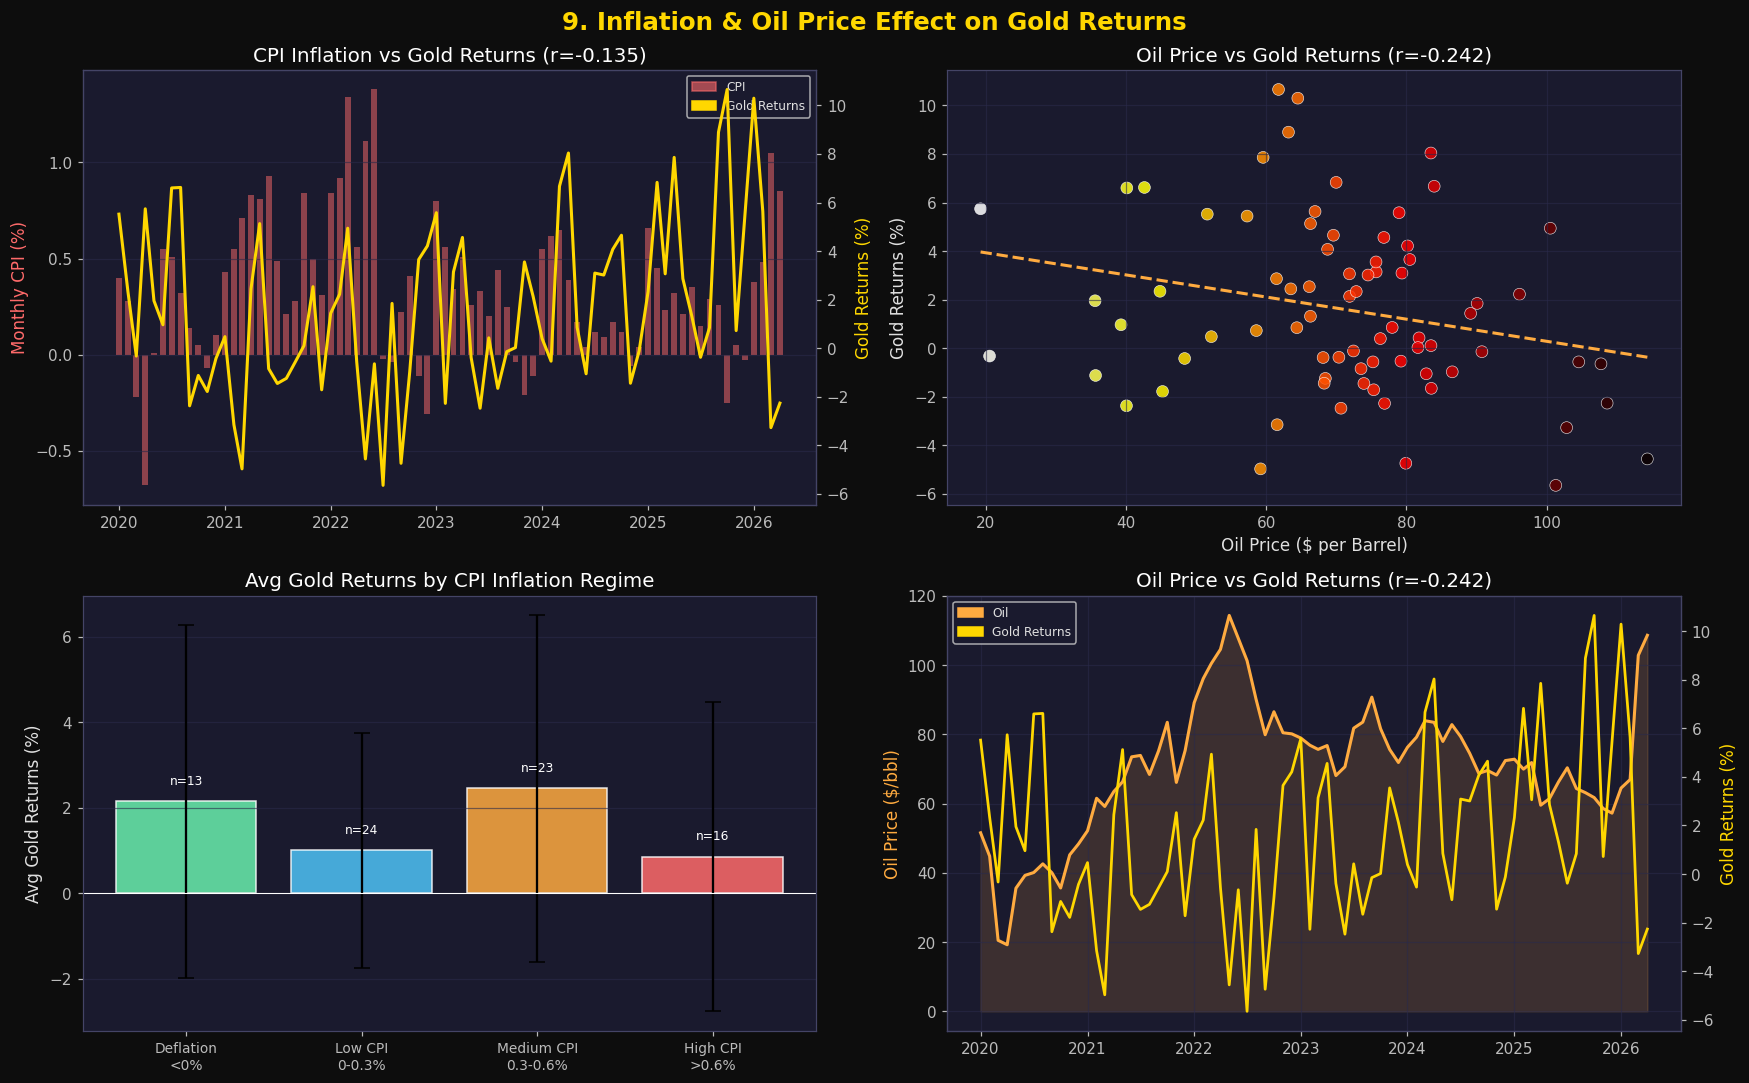


📌 INFLATION & OIL INSIGHTS:
  • CPI vs Gold Returns   : r = -0.1348  (p = 0.2456)
  • Oil Price vs Gold     : r = -0.2424  (p = 0.0349)


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('9. Inflation & Oil Price Effect on Gold Returns', fontsize=16, fontweight='bold', color=GOLD, y=0.98)

corr_cpi, pval_cpi = pearsonr(df.CPI, df.Gold_Returns)
corr_oil, pval_oil = pearsonr(df.Oil_Price, df.Gold_Returns)

# --- Row 1 Col 1: CPI vs Gold Returns time series ---
ax1 = axes[0, 0]
ax2 = ax1.twinx()
ax1.bar(df.Date, df.CPI, color=RED, alpha=0.5, width=20, label='CPI Inflation')
ax2.plot(df.Date, df.Gold_Returns, color=GOLD, linewidth=2)
ax1.set_ylabel('Monthly CPI (%)', color=RED)
ax2.set_ylabel('Gold Returns (%)', color=GOLD)
ax1.set_title(f'CPI Inflation vs Gold Returns (r={corr_cpi:.3f})')
ax1.legend(handles=[mpatches.Patch(color=RED, alpha=0.6, label='CPI'),
                    mpatches.Patch(color=GOLD, label='Gold Returns')], fontsize=8)
ax1.grid(True, axis='y')

# --- Row 1 Col 2: Oil vs Gold Returns scatter ---
ax = axes[0, 1]
ax.scatter(df.Oil_Price, df.Gold_Returns, c=df.Oil_Price, cmap='hot_r',
           s=60, alpha=0.85, edgecolors='white', linewidths=0.4)
mo, bo = np.polyfit(df.Oil_Price, df.Gold_Returns, 1)
xro = np.linspace(df.Oil_Price.min(), df.Oil_Price.max(), 100)
ax.plot(xro, mo*xro+bo, color=ORANGE, linewidth=2, linestyle='--')
ax.set_xlabel('Oil Price ($ per Barrel)')
ax.set_ylabel('Gold Returns (%)')
ax.set_title(f'Oil Price vs Gold Returns (r={corr_oil:.3f})')
ax.grid(True)

# --- Row 2 Col 1: CPI regime vs Gold ---
ax = axes[1, 0]
cpi_bins = pd.cut(df.CPI, bins=[-2, 0, 0.3, 0.6, 5],
                  labels=['Deflation\n<0%', 'Low CPI\n0-0.3%', 'Medium CPI\n0.3-0.6%', 'High CPI\n>0.6%'])
cpi_means = df.groupby(cpi_bins, observed=False)['Gold_Returns'].mean()
cpi_counts = df.groupby(cpi_bins, observed=False)['Gold_Returns'].count()
cpi_stds = df.groupby(cpi_bins, observed=False)['Gold_Returns'].std()
bars_cpi = ax.bar(range(len(cpi_means)), cpi_means.values,
                  color=[GREEN, BLUE, ORANGE, RED], alpha=0.85, edgecolor='white',
                  yerr=cpi_stds.values, capsize=5, error_kw={'color': 'white', 'linewidth': 1.5})
ax.set_xticks(range(len(cpi_means)))
ax.set_xticklabels(cpi_means.index, fontsize=9)
for i, (v, n) in enumerate(zip(cpi_means.values, cpi_counts.values)):
    if not np.isnan(v):
        ax.text(i, v + 0.4, f'n={n}', ha='center', fontsize=8, color='white')
ax.axhline(0, color='white', linewidth=0.7)
ax.set_title('Avg Gold Returns by CPI Inflation Regime')
ax.set_ylabel('Avg Gold Returns (%)')
ax.grid(True, axis='y')

# --- Row 2 Col 2: Dual axis Oil + Gold ---
ax1 = axes[1, 1]
ax2 = ax1.twinx()
ax1.plot(df.Date, df.Oil_Price, color=ORANGE, linewidth=2, label='Oil Price')
ax1.fill_between(df.Date, df.Oil_Price, color=ORANGE, alpha=0.15)
ax2.plot(df.Date, df.Gold_Returns, color=GOLD, linewidth=1.8)
ax1.set_ylabel('Oil Price ($/bbl)', color=ORANGE)
ax2.set_ylabel('Gold Returns (%)', color=GOLD)
ax1.set_title(f'Oil Price vs Gold Returns (r={corr_oil:.3f})')
ax1.legend(handles=[mpatches.Patch(color=ORANGE, label='Oil'),
                    mpatches.Patch(color=GOLD, label='Gold Returns')], fontsize=8)
ax1.grid(True)

plt.tight_layout()
plt.savefig('fig9_inflation_oil.png', bbox_inches='tight', dpi=120)
plt.show()

print(f"\n📌 INFLATION & OIL INSIGHTS:")
print(f"  • CPI vs Gold Returns   : r = {corr_cpi:.4f}  (p = {pval_cpi:.4f})")
print(f"  • Oil Price vs Gold     : r = {corr_oil:.4f}  (p = {pval_oil:.4f})")

---
## 10. Full Regression Analysis of Gold Returns

In [28]:
# ── OLS Regression: Final Model ──────────────────────────────────────────────
import pandas as pd
from statsmodels.api import OLS, add_constant

# Create required transformed variables
df['Gold_Returns_Lag1'] = df['Gold_Returns'].shift(1)
df['CB_Demand_Lag1'] = df['CB_Demand'].shift(1)
df['D_USD_Index'] = df['USD_Index'].diff()

# Select final regression variables
reg_df = df[
    [
        'Gold_Returns',
        'ETF_Demand',
        'CB_Demand_Lag1',
        'D_USD_Index',
        'Gold_Returns_Lag1'
    ]
].dropna()

# Independent variables
feature_cols = [
    'ETF_Demand',
    'CB_Demand_Lag1',
    'D_USD_Index',
    'Gold_Returns_Lag1'
]

# Better labels for tables/graphs
labels = [
    'ETF Demand',
    'CB Demand (-1)',
    'Change in USD Index',
    'Gold Returns (-1)'
]

# Define X and y
X = add_constant(reg_df[feature_cols])
y = reg_df['Gold_Returns']

# Estimate OLS model
model_full = OLS(y, X).fit()

# Print result
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:           Gold_Returns   R-squared:                       0.439
Model:                            OLS   Adj. R-squared:                  0.407
Method:                 Least Squares   F-statistic:                     13.70
Date:                Mon, 25 May 2026   Prob (F-statistic):           2.67e-08
Time:                        18:38:50   Log-Likelihood:                -180.26
No. Observations:                  75   AIC:                             370.5
Df Residuals:                      70   BIC:                             382.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.2734      0.47

In [29]:
# ── Clean Regression Output Table ────────────────────────────────────────────

results_table = pd.DataFrame({
    'Variable': ['Constant'] + labels,
    'Coefficient': model_final.params.values,
    'Std. Error': model_final.bse.values,
    't-Statistic': model_final.tvalues.values,
    'p-Value': model_final.pvalues.values
})

results_table

,Variable,Coefficient,Std. Error,t-Statistic,p-Value
0,Constant,0.273391,0.473544,0.577329,0.565570
1,ETF Demand,0.024061,0.005244,4.588044,0.000019
2,CB Demand (-1),0.019316,0.009883,1.954514,0.054636
3,Change in USD Index,-0.540038,0.166812,-3.237416,0.001845
4,Gold Returns (-1),0.254916,0.096999,2.628023,0.010547


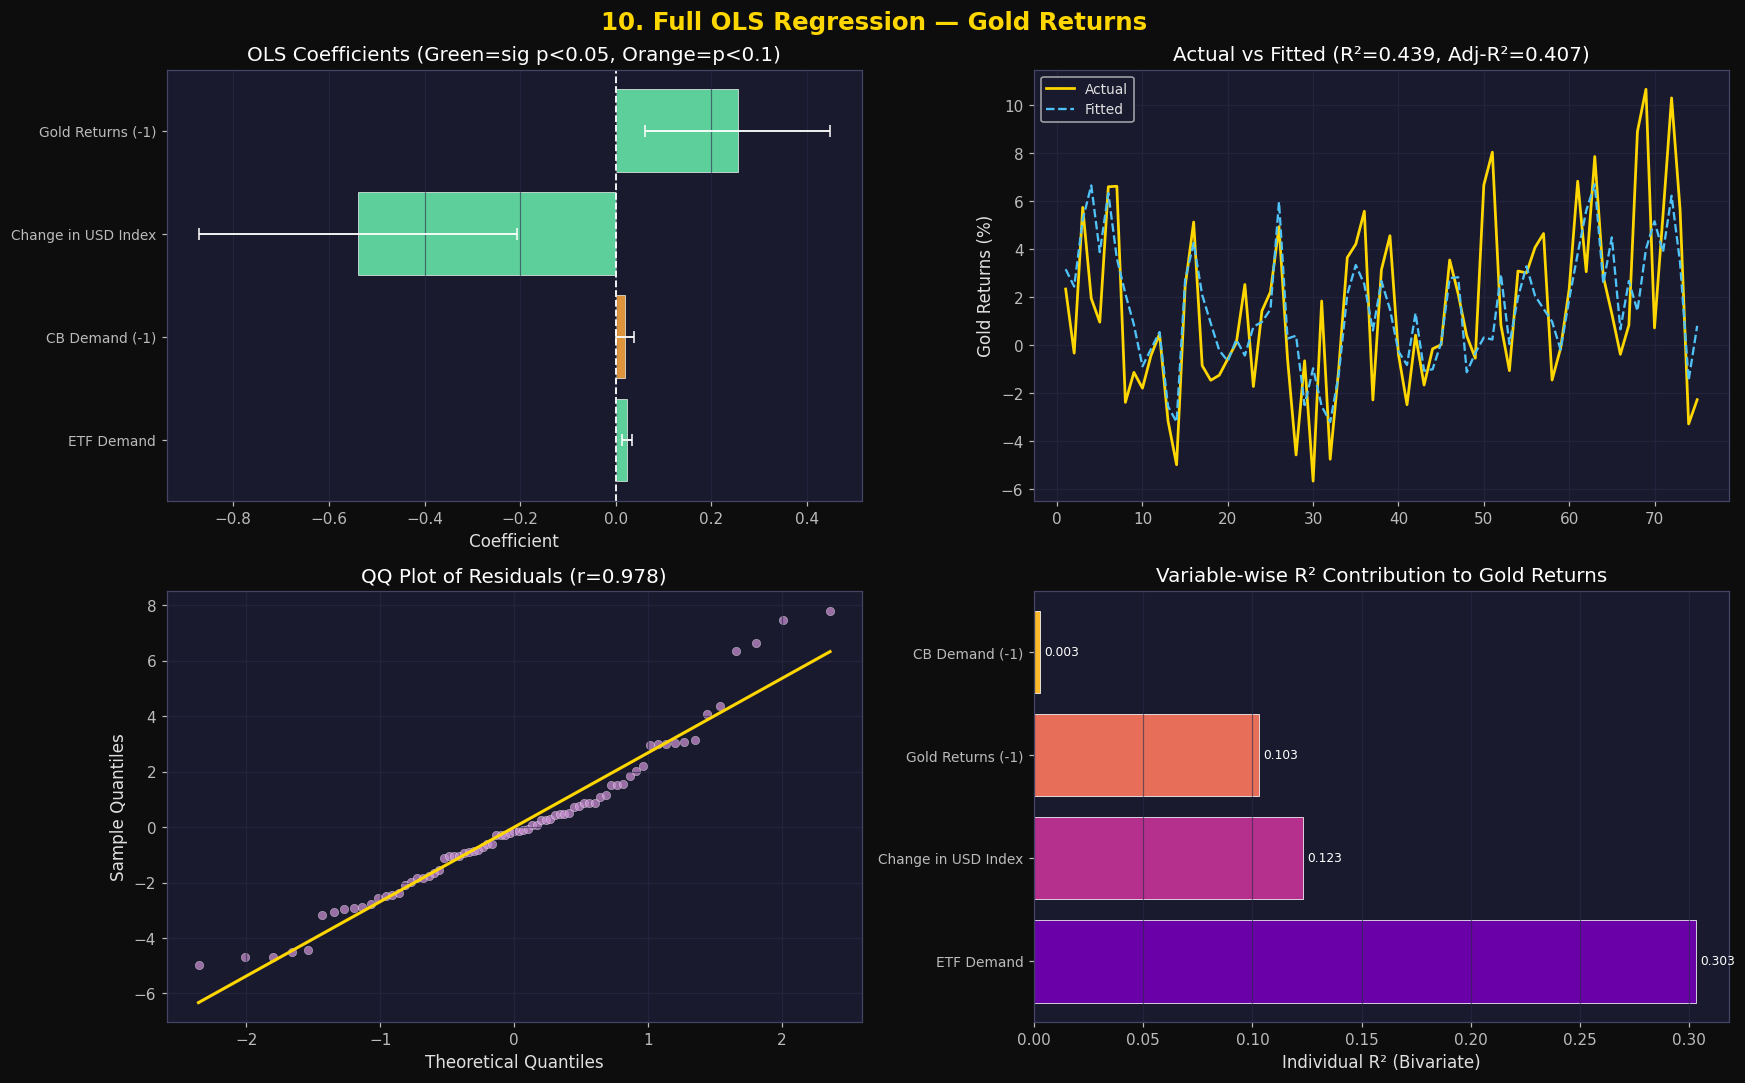


📌 REGRESSION SUMMARY:
  • R²          = 0.4391
  • Adj-R²      = 0.4070
  • F-statistic = 13.70  (p = 0.0000)
  • DW Statistic = 1.961  (2.0 = no autocorrelation)

  Significant predictors (p < 0.05):
    ✅ ETF Demand (coef=0.0241, p=0.0000)
    ✅ Change in USD Index (coef=-0.5400, p=0.0018)
    ✅ Gold Returns (-1) (coef=0.2549, p=0.0105)


In [30]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('10. Full OLS Regression — Gold Returns', fontsize=16, fontweight='bold', color=GOLD, y=0.98)

# --- Row 1 Col 1: Coefficient Plot ---
ax = axes[0, 0]
params = model_full.params[1:]  # exclude intercept
conf = model_full.conf_int().iloc[1:]
pvals = model_full.pvalues[1:]
bar_c = [GREEN if p < 0.05 else ORANGE if p < 0.1 else '#666688' for p in pvals]
y_pos = range(len(params))
ax.barh(y_pos, params.values, color=bar_c, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.errorbar(params.values, list(y_pos),
            xerr=[params.values - conf.iloc[:, 0], conf.iloc[:, 1] - params.values],
            fmt='none', color='white', capsize=4, linewidth=1.2)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(labels, fontsize=9)
ax.axvline(0, color='white', linewidth=1.2, linestyle='--')
ax.set_xlabel('Coefficient')
ax.set_title('OLS Coefficients (Green=sig p<0.05, Orange=p<0.1)')
ax.grid(True, axis='x')

# --- Row 1 Col 2: Fitted vs Actual ---
ax = axes[0, 1]
ax.plot(reg_df.index if hasattr(reg_df,'index') else range(len(y)),
        y.values, color=GOLD, linewidth=1.8, label='Actual')
ax.plot(reg_df.index if hasattr(reg_df,'index') else range(len(y)),
        model_full.fittedvalues.values, color=BLUE, linewidth=1.5,
        linestyle='--', label='Fitted')
ax.set_title(f'Actual vs Fitted (R²={model_full.rsquared:.3f}, Adj-R²={model_full.rsquared_adj:.3f})')
ax.set_ylabel('Gold Returns (%)')
ax.legend(fontsize=9)
ax.grid(True)

# --- Row 2 Col 1: Residuals QQ Plot ---
ax = axes[1, 0]
residuals = model_full.resid
(osm, osr), (slope, intercept, r_sq) = stats.probplot(residuals)
ax.scatter(osm, osr, color=PURPLE, s=30, alpha=0.7, edgecolors='white', linewidths=0.3)
line_x = np.array([min(osm), max(osm)])
ax.plot(line_x, slope * line_x + intercept, color=GOLD, linewidth=2)
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')
ax.set_title(f'QQ Plot of Residuals (r={r_sq:.3f})')
ax.grid(True)

# --- Row 2 Col 2: R² Contribution ---
ax = axes[1, 1]
individual_r2 = {lbl: pearsonr(reg_df[col], reg_df['Gold_Returns'])[0]**2
                 for col, lbl in zip(feature_cols, labels)}
sorted_r2 = sorted(individual_r2.items(), key=lambda x: x[1], reverse=True)
names_r2 = [x[0] for x in sorted_r2]
vals_r2  = [x[1] for x in sorted_r2]
bar_palette = plt.cm.plasma(np.linspace(0.2, 0.85, len(vals_r2)))
bars_r2 = ax.barh(range(len(vals_r2)), vals_r2, color=bar_palette, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(names_r2)))
ax.set_yticklabels(names_r2, fontsize=9)
for i, v in enumerate(vals_r2):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=8, color='white')
ax.set_xlabel('Individual R² (Bivariate)')
ax.set_title('Variable-wise R² Contribution to Gold Returns')
ax.grid(True, axis='x')

plt.tight_layout()
plt.savefig('fig10_regression.png', bbox_inches='tight', dpi=120)
plt.show()

print(f"\n📌 REGRESSION SUMMARY:")
print(f"  • R²          = {model_full.rsquared:.4f}")
print(f"  • Adj-R²      = {model_full.rsquared_adj:.4f}")
print(f"  • F-statistic = {model_full.fvalue:.2f}  (p = {model_full.f_pvalue:.4f})")
print(f"  • DW Statistic = {durbin_watson(residuals):.3f}  (2.0 = no autocorrelation)")
print(f"\n  Significant predictors (p < 0.05):")
sig = model_full.pvalues[model_full.pvalues < 0.05].index.tolist()
for s in sig:
    lbl = labels[feature_cols.index(s)] if s in feature_cols else s
    print(f"    ✅ {lbl} (coef={model_full.params[s]:.4f}, p={model_full.pvalues[s]:.4f})")

In [31]:
# ── Stationarity Tests: ADF Only ─────────────────────────────────────────────
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller

test_cols = {
    'Gold_Returns':   'Gold Returns',
    'ETF_Demand':     'ETF Demand',
    'CB_Demand':      'CB Demand',
    'Total_Demand':   'Total Demand',
    'USD_Index':      'USD Index',
    'Treasury_Yield': '10Y Treasury Yield',
    'FED_Rate':       'FED Rate',
    'CPI':            'CPI Inflation',
    'Oil_Price':      'Oil Price',
    'SP500_Return':   'S&P 500 Return'
}

adf_results = []
need_difference = []

print("=" * 70)
print(f"{'Variable':<24} {'ADF Stat':>10} {'ADF p-value':>13} {'Decision':>18}")
print("=" * 70)

for col, name in test_cols.items():
    s = df[col].dropna()

    adf_stat, adf_p, _, _, _, _ = adfuller(s, autolag='AIC')

    if adf_p < 0.05:
        decision = "Stationary"
    else:
        decision = "Needs Difference"
        need_difference.append(col)

    print(f"{name:<24} {adf_stat:>10.3f} {adf_p:>13.4f} {decision:>18}")

    adf_results.append({
        'Variable': name,
        'Column_Name': col,
        'ADF_stat': adf_stat,
        'ADF_p_value': adf_p,
        'Stationary': adf_p < 0.05,
        'Needs_Difference': adf_p >= 0.05
    })

print("=" * 70)

adf_df_results = pd.DataFrame(adf_results)

print("\nVariables that need first difference based on ADF test:")
print(need_difference)

Variable                   ADF Stat   ADF p-value           Decision
Gold Returns                 -6.126        0.0000         Stationary
ETF Demand                   -4.285        0.0005         Stationary
CB Demand                    -4.580        0.0001         Stationary
Total Demand                 -4.979        0.0000         Stationary
USD Index                    -2.093        0.2473   Needs Difference
10Y Treasury Yield           -0.866        0.7988   Needs Difference
FED Rate                     -1.774        0.3934   Needs Difference
CPI Inflation                -2.098        0.2452   Needs Difference
Oil Price                    -1.922        0.3216   Needs Difference
S&P 500 Return               -9.507        0.0000         Stationary

Variables that need first difference based on ADF test:
['USD_Index', 'Treasury_Yield', 'FED_Rate', 'CPI', 'Oil_Price']


In [32]:
# ── Create First Difference Variables ────────────────────────────────────────

for col in need_difference:
    df[f'D_{col}'] = df[col].diff()

print("First-difference variables created:")
for col in need_difference:
    print(f"D_{col}")

First-difference variables created:
D_USD_Index
D_Treasury_Yield
D_FED_Rate
D_CPI
D_Oil_Price


In [33]:
# ── Full OLS Regression with ADF-Corrected Variables ─────────────────────────
import pandas as pd
from statsmodels.api import OLS, add_constant

# Create first differences for non-stationary variables
df['D_USD_Index'] = df['USD_Index'].diff()
df['D_Treasury_Yield'] = df['Treasury_Yield'].diff()
df['D_FED_Rate'] = df['FED_Rate'].diff()
df['D_CPI'] = df['CPI'].diff()
df['D_Oil_Price'] = df['Oil_Price'].diff()

# Create lag variables
df['CB_Demand_Lag1'] = df['CB_Demand'].shift(1)
df['Gold_Returns_Lag1'] = df['Gold_Returns'].shift(1)

# Regression dataframe
reg_df = df[
    [
        'Gold_Returns',
        'ETF_Demand',
        'CB_Demand_Lag1',
        'D_USD_Index',
        'D_Treasury_Yield',
        'D_FED_Rate',
        'D_CPI',
        'D_Oil_Price',
        'SP500_Return',
        'Gold_Returns_Lag1'
    ]
].dropna()

# Independent variables
feature_cols = [
    'ETF_Demand',
    'CB_Demand_Lag1',
    'D_USD_Index',
    'D_Treasury_Yield',
    'D_FED_Rate',
    'D_CPI',
    'D_Oil_Price',
    'SP500_Return',
    'Gold_Returns_Lag1'
]

# Labels for cleaner output
labels = [
    'ETF Demand',
    'CB Demand (-1)',
    'Change in USD Index',
    'Change in 10Y Treasury Yield',
    'Change in FED Rate',
    'Change in CPI',
    'Change in Oil Price',
    'S&P 500 Return',
    'Gold Returns (-1)'
]

# Define X and y
X = add_constant(reg_df[feature_cols])
y = reg_df['Gold_Returns']

# Run OLS
model_full_adf = OLS(y, X).fit()

# Print full regression result
print(model_full_adf.summary())

                            OLS Regression Results                            
Dep. Variable:           Gold_Returns   R-squared:                       0.464
Model:                            OLS   Adj. R-squared:                  0.390
Method:                 Least Squares   F-statistic:                     6.257
Date:                Mon, 25 May 2026   Prob (F-statistic):           2.55e-06
Time:                        18:45:41   Log-Likelihood:                -178.54
No. Observations:                  75   AIC:                             377.1
Df Residuals:                      65   BIC:                             400.3
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.1952      0.53

In [34]:
# ── Clean Regression Output Table ────────────────────────────────────────────

results_table = pd.DataFrame({
    'Variable': ['Constant'] + labels,
    'Coefficient': model_full_adf.params.values,
    'Std. Error': model_full_adf.bse.values,
    't-Statistic': model_full_adf.tvalues.values,
    'p-Value': model_full_adf.pvalues.values
})

results_table = results_table.round(4)
results_table

,Variable,Coefficient,Std. Error,t-Statistic,p-Value
0,Constant,0.1952,0.5377,0.3630,0.7178
1,ETF Demand,0.0230,0.0063,3.6757,0.0005
2,CB Demand (-1),0.0210,0.0101,2.0733,0.0421
3,Change in USD Index,-0.6789,0.2463,-2.7565,0.0076
4,Change in 10Y Treasury Yield,1.7607,1.5719,1.1201,0.2668
5,Change in FED Rate,-0.2247,1.7682,-0.1271,0.8993
6,Change in CPI,0.5249,1.0137,0.5178,0.6063
7,Change in Oil Price,-0.0767,0.0497,-1.5446,0.1273
8,S&P 500 Return,-0.0033,0.0886,-0.0376,0.9701
9,Gold Returns (-1),0.2841,0.1014,2.8012,0.0067


In [35]:
# ── Alternative Model: Total Demand Instead of ETF + CB ──────────────────────

df['Gold_Returns_Lag1'] = df['Gold_Returns'].shift(1)

reg_df_total = df[
    [
        'Gold_Returns',
        'Total_Demand',
        'D_USD_Index',
        'D_Treasury_Yield',
        'D_FED_Rate',
        'D_CPI',
        'D_Oil_Price',
        'SP500_Return',
        'Gold_Returns_Lag1'
    ]
].dropna()

feature_cols_total = [
    'Total_Demand',
    'D_USD_Index',
    'D_Treasury_Yield',
    'D_FED_Rate',
    'D_CPI',
    'D_Oil_Price',
    'SP500_Return',
    'Gold_Returns_Lag1'
]

X_total = add_constant(reg_df_total[feature_cols_total])
y_total = reg_df_total['Gold_Returns']

model_total = OLS(y_total, X_total).fit()

print(model_total.summary())

                            OLS Regression Results                            
Dep. Variable:           Gold_Returns   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.301
Method:                 Least Squares   F-statistic:                     4.985
Date:                Mon, 25 May 2026   Prob (F-statistic):           7.45e-05
Time:                        18:48:01   Log-Likelihood:                -184.21
No. Observations:                  75   AIC:                             386.4
Df Residuals:                      66   BIC:                             407.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.5714      0.53

---
## 11. Causality Tests (Granger Causality)

In [37]:
# ── Granger Causality Tests ────────────────────────────────────────────────────
print("="*65)
print("  GRANGER CAUSALITY TESTS  →  Does X Granger-cause Gold Returns?")
print("="*65)

predictors = {
    'ETF_Demand':       'ETF Net Demand',
    'CB_Demand':        'Central Bank Demand',
    'Total_Demand':     'Total Net Demand',
    'USD_Index':        'USD Index',
    'Treasury_Yield':   '10Y Treasury Yield',
    'FED_Rate':         'FED Fund Rate',
    'CPI':              'CPI Inflation',
    'Oil_Price':        'Oil Price',
    'SP500_Return':     'S&P 500 Return',
    'Real_Rate':        'Real Interest Rate',
}

granger_results = {}
max_lag = 4

for col, name in predictors.items():
    data_pair = df[['Gold_Returns', col]].dropna()
    try:
        gc_test = grangercausalitytests(data_pair, maxlag=max_lag, verbose=False)
        min_pval = min(gc_test[lag][0]['ssr_ftest'][1] for lag in range(1, max_lag+1))
        best_lag = min(range(1, max_lag+1), key=lambda l: gc_test[l][0]['ssr_ftest'][1])
        granger_results[name] = {'p_value': min_pval, 'best_lag': best_lag, 'col': col}
        sig = "✅ GRANGER CAUSES" if min_pval < 0.1 else "❌ Does not Granger cause"
        print(f"  {name:<28}: p={min_pval:.4f}  (best lag={best_lag}m)  {sig}")
    except Exception as e:
        print(f"  {name}: ERROR - {e}")

print("\n  ℹ️  Granger causality ≠ true causality. It tests predictive power in time series.")

  GRANGER CAUSALITY TESTS  →  Does X Granger-cause Gold Returns?
  ETF Net Demand              : p=0.2306  (best lag=1m)  ❌ Does not Granger cause
  Central Bank Demand         : p=0.2435  (best lag=1m)  ❌ Does not Granger cause
  Total Net Demand            : p=0.0759  (best lag=1m)  ✅ GRANGER CAUSES
  USD Index                   : p=0.0018  (best lag=2m)  ✅ GRANGER CAUSES
  10Y Treasury Yield          : p=0.0366  (best lag=2m)  ✅ GRANGER CAUSES
  FED Fund Rate               : p=0.0084  (best lag=2m)  ✅ GRANGER CAUSES
  CPI Inflation               : p=0.0155  (best lag=4m)  ✅ GRANGER CAUSES
  Oil Price                   : p=0.3353  (best lag=1m)  ❌ Does not Granger cause
  S&P 500 Return              : p=0.1790  (best lag=4m)  ❌ Does not Granger cause
  Real Interest Rate          : p=0.0251  (best lag=4m)  ✅ GRANGER CAUSES

  ℹ️  Granger causality ≠ true causality. It tests predictive power in time series.


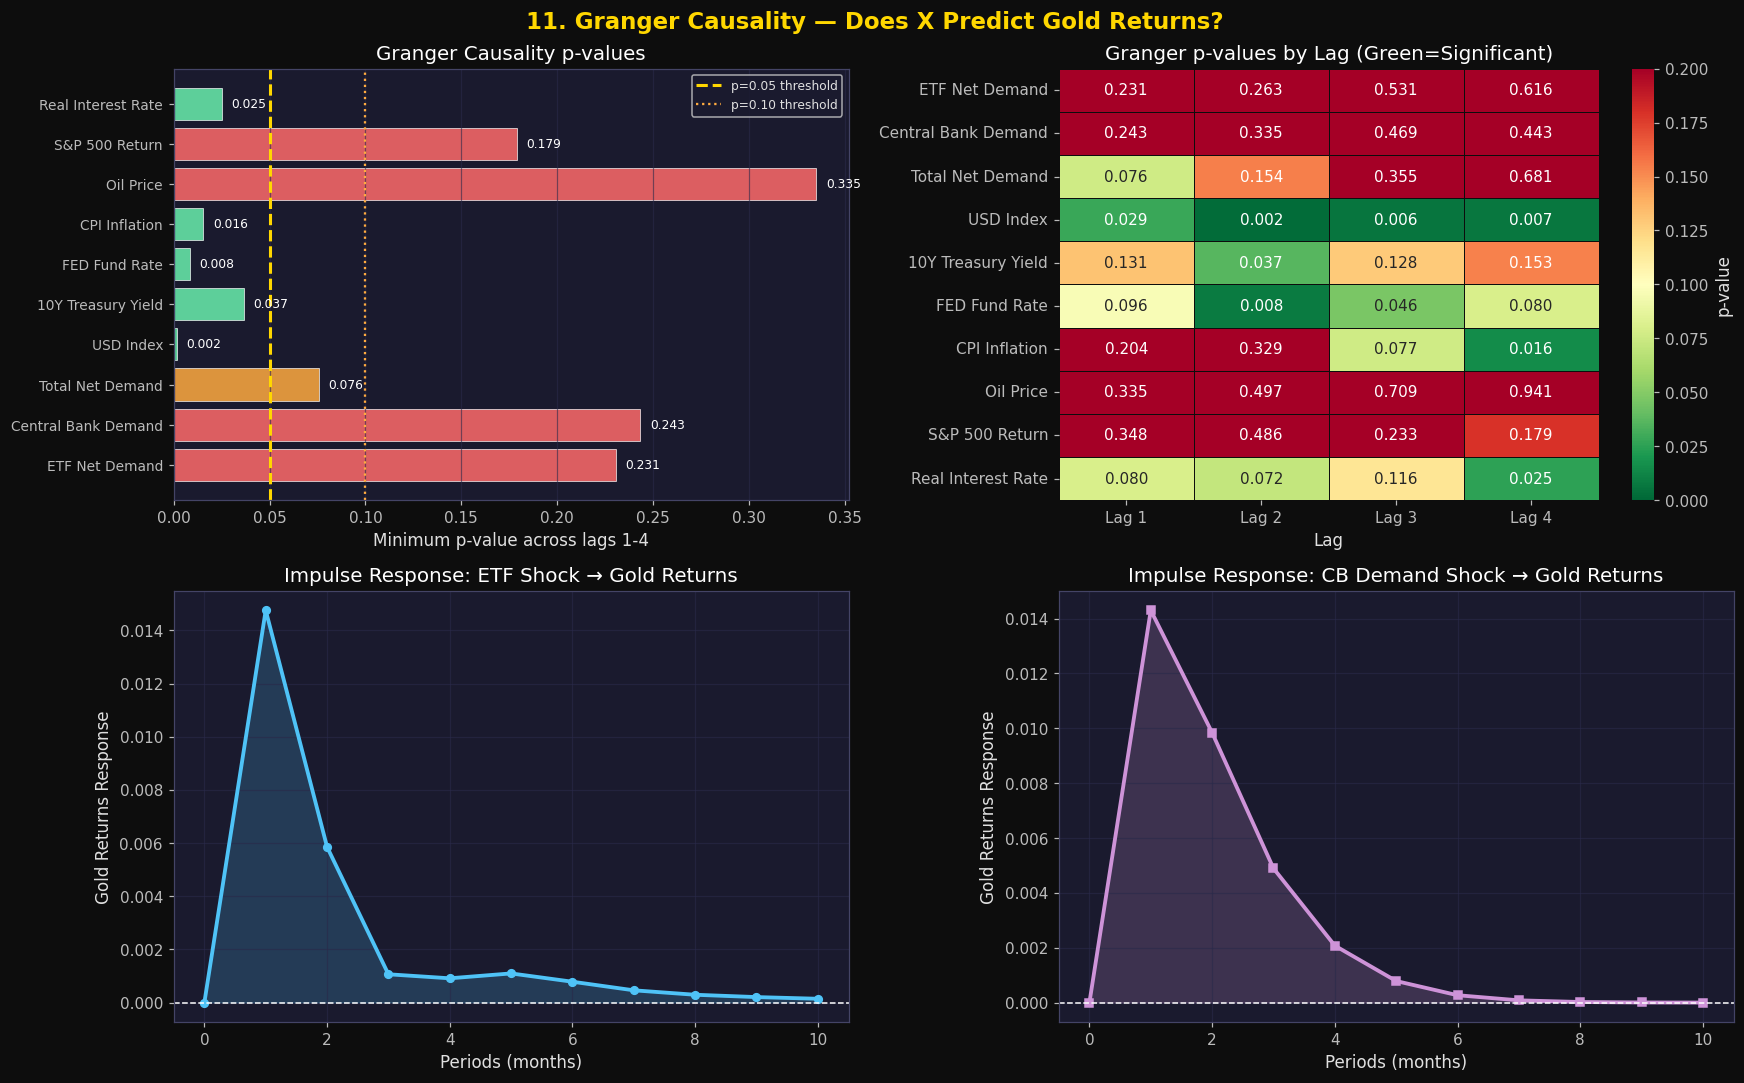

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('11. Granger Causality — Does X Predict Gold Returns?',
             fontsize=15, fontweight='bold', color=GOLD, y=0.98)

# --- Row 1 Col 1: Granger p-value bar chart ---
ax = axes[0, 0]
names = list(granger_results.keys())
pvals_g = [granger_results[n]['p_value'] for n in names]
g_colors = [GREEN if p < 0.05 else ORANGE if p < 0.1 else RED for p in pvals_g]
bars_g = ax.barh(range(len(names)), pvals_g, color=g_colors, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.axvline(0.05, color=GOLD, linewidth=2, linestyle='--', label='p=0.05 threshold')
ax.axvline(0.10, color=ORANGE, linewidth=1.5, linestyle=':', label='p=0.10 threshold')
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel('Minimum p-value across lags 1-4')
ax.set_title('Granger Causality p-values')
ax.legend(fontsize=8)
for i, p in enumerate(pvals_g):
    ax.text(p + 0.005, i, f'{p:.3f}', va='center', fontsize=8, color='white')
ax.grid(True, axis='x')

# --- Row 1 Col 2: Granger heat map across lags ---
ax = axes[0, 1]
lag_pval_matrix = np.zeros((len(predictors), max_lag))
pred_keys = list(predictors.keys())
pred_names = list(predictors.values())
for i, (col, name) in enumerate(predictors.items()):
    data_pair = df[['Gold_Returns', col]].dropna()
    try:
        gc = grangercausalitytests(data_pair, maxlag=max_lag, verbose=False)
        for lag in range(1, max_lag+1):
            lag_pval_matrix[i, lag-1] = gc[lag][0]['ssr_ftest'][1]
    except:
        lag_pval_matrix[i, :] = np.nan

lag_df = pd.DataFrame(lag_pval_matrix, index=pred_names,
                      columns=[f'Lag {l}' for l in range(1, max_lag+1)])
sns.heatmap(lag_df, annot=True, fmt='.3f', cmap='RdYlGn_r', ax=ax,
            vmin=0, vmax=0.2, linewidths=0.5, linecolor='#0d0d0d',
            cbar_kws={'label': 'p-value'})
ax.set_title('Granger p-values by Lag (Green=Significant)')
ax.set_xlabel('Lag')

# --- Row 2 Col 1: VAR impulse-like — ETF → Gold ---
ax = axes[1, 0]
var_data = df[['Gold_Returns','ETF_Demand']].dropna()
var_model = VAR(var_data)
var_fit = var_model.fit(maxlags=4, ic='aic')
irf = var_fit.irf(10)
irf_vals = irf.irfs[:, 0, 1]  # Gold response to ETF shock
ax.plot(range(len(irf_vals)), irf_vals, color=BLUE, linewidth=2.5, marker='o', markersize=5)
ax.fill_between(range(len(irf_vals)), irf_vals, color=BLUE, alpha=0.2)
ax.axhline(0, color='white', linewidth=1, linestyle='--')
ax.set_title('Impulse Response: ETF Shock → Gold Returns')
ax.set_xlabel('Periods (months)')
ax.set_ylabel('Gold Returns Response')
ax.grid(True)

# --- Row 2 Col 2: VAR impulse — CB → Gold ---
ax = axes[1, 1]
var_data2 = df[['Gold_Returns','CB_Demand']].dropna()
var_model2 = VAR(var_data2)
var_fit2 = var_model2.fit(maxlags=4, ic='aic')
irf2 = var_fit2.irf(10)
irf_vals2 = irf2.irfs[:, 0, 1]
ax.plot(range(len(irf_vals2)), irf_vals2, color=PURPLE, linewidth=2.5, marker='s', markersize=5)
ax.fill_between(range(len(irf_vals2)), irf_vals2, color=PURPLE, alpha=0.2)
ax.axhline(0, color='white', linewidth=1, linestyle='--')
ax.set_title('Impulse Response: CB Demand Shock → Gold Returns')
ax.set_xlabel('Periods (months)')
ax.set_ylabel('Gold Returns Response')
ax.grid(True)

plt.tight_layout()
plt.savefig('fig11_granger.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 13. Correlation Matrix & Key Insights Dashboard

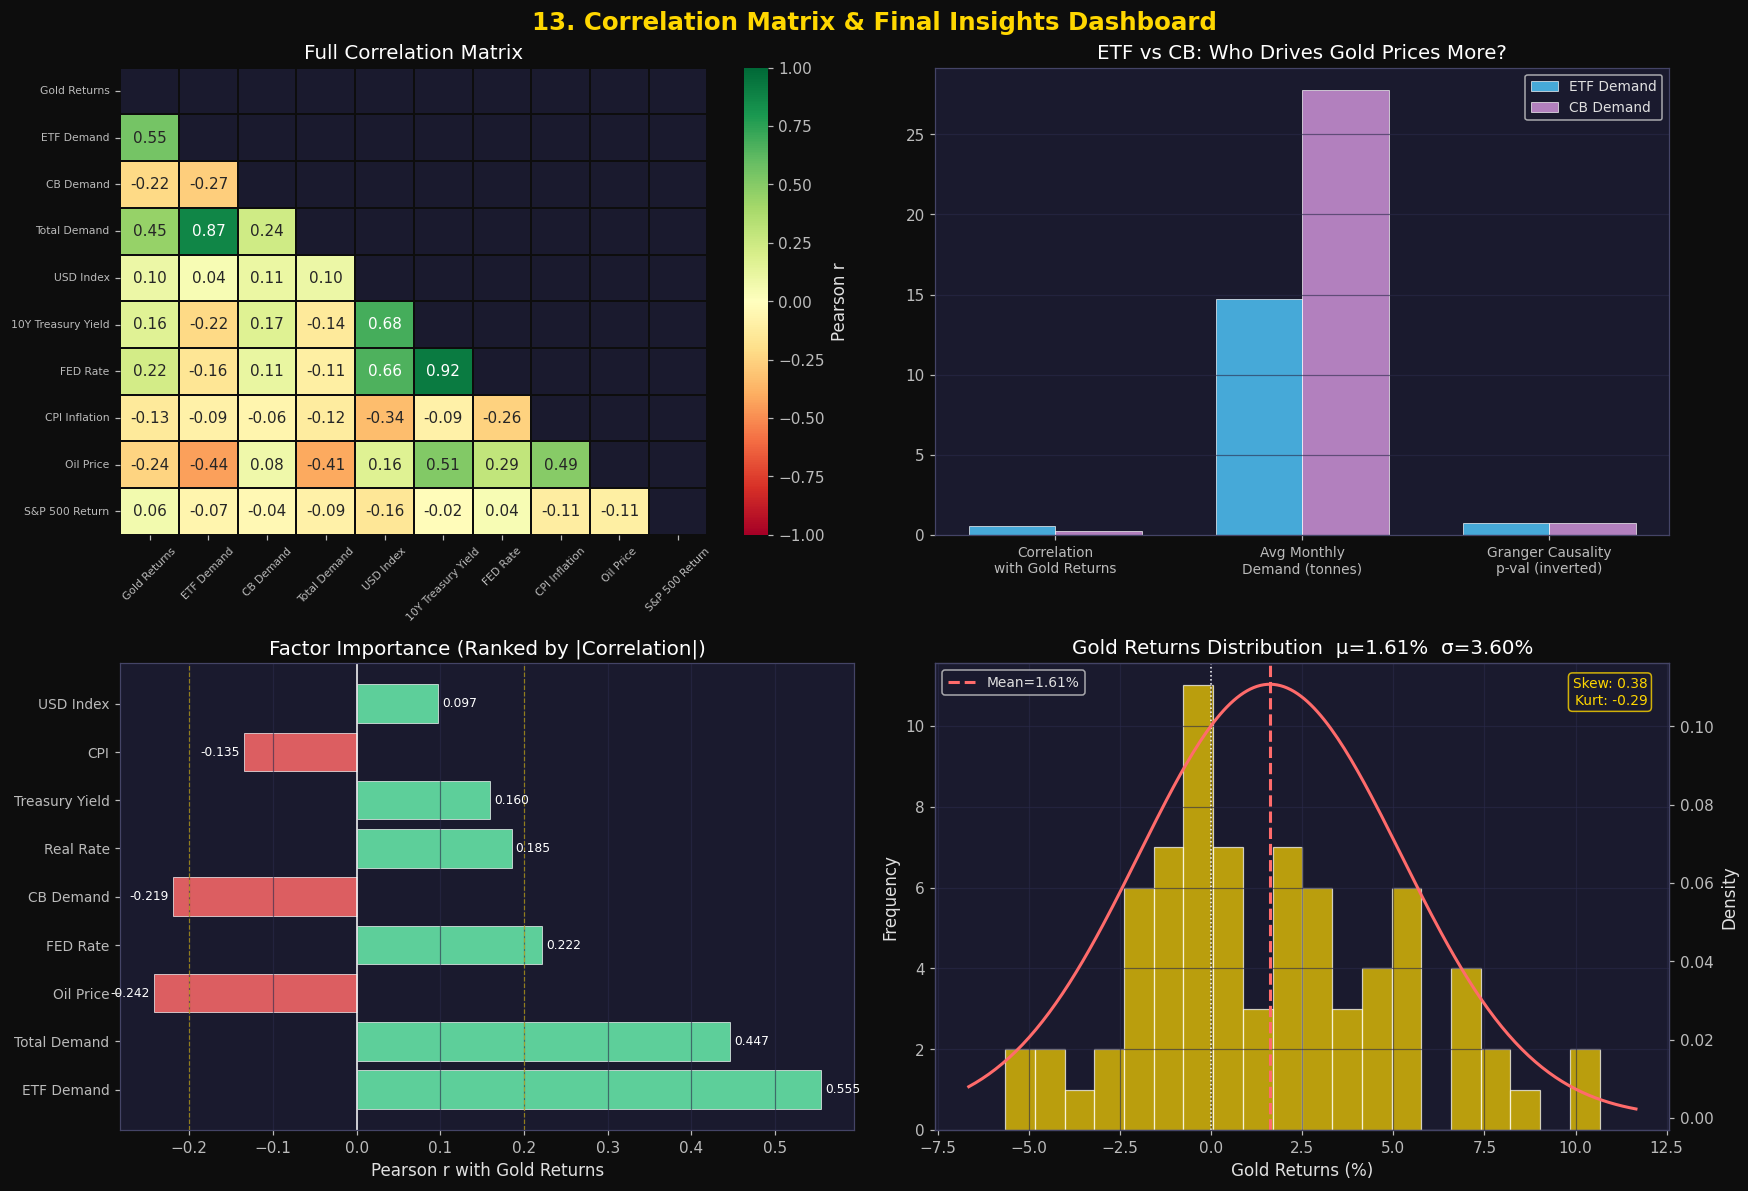

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('13. Correlation Matrix & Final Insights Dashboard',
             fontsize=16, fontweight='bold', color=GOLD, y=0.98)

# --- Row 1 Col 1: Correlation Heatmap ---
ax = axes[0, 0]
corr_matrix = df[list(test_cols.keys())].dropna().corr()
corr_matrix.index   = list(test_cols.values())
corr_matrix.columns = list(test_cols.values())
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=ax, linewidths=0.3, linecolor='#0d0d0d',
            vmin=-1, vmax=1, center=0,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Full Correlation Matrix')
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', labelsize=7)

# --- Row 1 Col 2: ETF vs CB: final verdict bar ---
ax = axes[0, 1]
metrics = {
    'Correlation\nwith Gold Returns': [abs(corr), abs(corr_cb)],
    'Avg Monthly\nDemand (tonnes)': [df.ETF_Demand.mean(), df.CB_Demand.mean()],
    'Granger Causality\np-val (inverted)': [
        1 - granger_results.get('ETF Net Demand', {'p_value': 0.5})['p_value'],
        1 - granger_results.get('Central Bank Demand', {'p_value': 0.5})['p_value']
    ]
}
x_m = np.arange(len(metrics))
w_m = 0.35
b_e = ax.bar(x_m - w_m/2, [v[0] for v in metrics.values()], w_m,
             color=BLUE, alpha=0.85, label='ETF Demand', edgecolor='white', linewidth=0.5)
b_c = ax.bar(x_m + w_m/2, [v[1] for v in metrics.values()], w_m,
             color=PURPLE, alpha=0.85, label='CB Demand', edgecolor='white', linewidth=0.5)
ax.set_xticks(x_m)
ax.set_xticklabels(list(metrics.keys()), fontsize=9)
ax.set_title('ETF vs CB: Who Drives Gold Prices More?')
ax.legend(fontsize=9)
ax.grid(True, axis='y')

# --- Row 2 Col 1: Key Factor Summary ---
ax = axes[1, 0]
factor_corrs = {
    'ETF Demand': corr,
    'CB Demand':  corr_cb,
    'Total Demand': corr_tot,
    'USD Index': corr_usd,
    'FED Rate': corr_fed,
    'Treasury Yield': corr_tsy,
    'Real Rate': corr_real,
    'CPI': corr_cpi,
    'Oil Price': corr_oil,
}
sorted_fc = sorted(factor_corrs.items(), key=lambda x: abs(x[1]), reverse=True)
fc_names = [x[0] for x in sorted_fc]
fc_vals  = [x[1] for x in sorted_fc]
fc_colors = [GREEN if v > 0 else RED for v in fc_vals]
ax.barh(range(len(fc_names)), fc_vals, color=fc_colors, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='white', linewidth=1)
ax.axvline( 0.2, color=GOLD, linewidth=0.8, linestyle='--', alpha=0.5)
ax.axvline(-0.2, color=GOLD, linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_yticks(range(len(fc_names)))
ax.set_yticklabels(fc_names, fontsize=9)
ax.set_xlabel('Pearson r with Gold Returns')
ax.set_title('Factor Importance (Ranked by |Correlation|)')
ax.grid(True, axis='x')
for i, v in enumerate(fc_vals):
    ax.text(v + 0.005 if v >= 0 else v - 0.005, i, f'{v:.3f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=8, color='white')

# --- Row 2 Col 2: Gold Returns distribution ---
ax = axes[1, 1]
ax.hist(df.Gold_Returns, bins=20, color=GOLD, alpha=0.7, edgecolor='white', linewidth=0.8)
mu, sigma = df.Gold_Returns.mean(), df.Gold_Returns.std()
x_norm = np.linspace(df.Gold_Returns.min() - 1, df.Gold_Returns.max() + 1, 200)
p_norm = stats.norm.pdf(x_norm, mu, sigma)
ax2_hist = ax.twinx()
ax2_hist.plot(x_norm, p_norm, color=RED, linewidth=2, label='Normal Fit')
ax.axvline(mu, color=RED, linewidth=2, linestyle='--', label=f'Mean={mu:.2f}%')
ax.axvline(0, color='white', linewidth=1, linestyle=':')
ax.set_xlabel('Gold Returns (%)')
ax.set_ylabel('Frequency')
ax2_hist.set_ylabel('Density')
ax.set_title(f'Gold Returns Distribution  μ={mu:.2f}%  σ={sigma:.2f}%')
sk = stats.skew(df.Gold_Returns)
kt = stats.kurtosis(df.Gold_Returns)
ax.text(0.97, 0.97, f'Skew: {sk:.2f}\nKurt: {kt:.2f}',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=9, color=GOLD,
        bbox=dict(boxstyle='round', facecolor='#1a1a2e', edgecolor=GOLD, alpha=0.8))
ax.legend(fontsize=9)
ax.grid(True)

plt.tight_layout()
plt.savefig('fig13_dashboard.png', bbox_inches='tight', dpi=120)
plt.show()

# # Region Wise Analysis

In [42]:
# ── Regional ETF Demand Regressions ──────────────────────────────────────────
import pandas as pd
from statsmodels.api import OLS, add_constant

# Create required transformed variables
df['CB_Demand_Lag1'] = df['CB_Demand'].shift(1)
df['Gold_Returns_Lag1'] = df['Gold_Returns'].shift(1)
df['D_USD_Index'] = df['USD_Index'].diff()

# Regional ETF demand variables
regional_vars = {
    'North America': 'North_America',
    'Europe': 'Europe',
    'Asia': 'Asia',
    'Others': 'Others'
}

# Store models and results
regional_models = {}
regional_results = []

for region_name, region_col in regional_vars.items():

    # Regression dataframe
    reg_df = df[
        [
            'Gold_Returns',
            region_col,
            'CB_Demand_Lag1',
            'D_USD_Index',
            'Gold_Returns_Lag1'
        ]
    ].dropna()

    # Independent variables
    feature_cols = [
        region_col,
        'CB_Demand_Lag1',
        'D_USD_Index',
        'Gold_Returns_Lag1'
    ]

    X = add_constant(reg_df[feature_cols])
    y = reg_df['Gold_Returns']

    # Run regression
    model = OLS(y, X).fit()

    # Save model
    regional_models[region_name] = model

    # Save key results
    regional_results.append({
        'Region Model': region_name,
        'Region Coefficient': model.params[region_col],
        'Region p-value': model.pvalues[region_col],
        'CB Demand(-1) Coefficient': model.params['CB_Demand_Lag1'],
        'CB Demand(-1) p-value': model.pvalues['CB_Demand_Lag1'],
        'D USD Index Coefficient': model.params['D_USD_Index'],
        'D USD Index p-value': model.pvalues['D_USD_Index'],
        'Gold Returns(-1) Coefficient': model.params['Gold_Returns_Lag1'],
        'Gold Returns(-1) p-value': model.pvalues['Gold_Returns_Lag1'],
        'R-squared': model.rsquared,
        'Adj. R-squared': model.rsquared_adj,
        'F-stat p-value': model.f_pvalue,
        'Observations': int(model.nobs)
    })

    print("=" * 90)
    print(f"Regression Model: {region_name} ETF Demand")
    print("=" * 90)
    print(model.summary())
    print("\n\n")

# Convert summary results into dataframe
regional_results_df = pd.DataFrame(regional_results)

regional_results_df.round(4)

Regression Model: North America ETF Demand
                            OLS Regression Results                            
Dep. Variable:           Gold_Returns   R-squared:                       0.469
Model:                            OLS   Adj. R-squared:                  0.439
Method:                 Least Squares   F-statistic:                     15.46
Date:                Mon, 25 May 2026   Prob (F-statistic):           4.15e-09
Time:                        18:56:07   Log-Likelihood:                -178.20
No. Observations:                  75   AIC:                             366.4
Df Residuals:                      70   BIC:                             378.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

,Region Model,Region Coefficient,Region p-value,CB Demand(-1) Coefficient,CB Demand(-1) p-value,D USD Index Coefficient,D USD Index p-value,Gold Returns(-1) Coefficient,Gold Returns(-1) p-value,R-squared,Adj. R-squared,F-stat p-value,Observations
0,North America,0.0405,0.0000,0.0189,0.0533,-0.4793,0.0048,0.2226,0.0229,0.4691,0.4387,0.0000,75
1,Europe,0.0199,0.1702,0.0191,0.0925,-0.6997,0.0003,0.3902,0.0004,0.2899,0.2493,0.0001,75
2,Asia,0.0925,0.0021,0.0129,0.2265,-0.6159,0.0008,0.2573,0.0187,0.3630,0.3266,0.0000,75
3,Others,0.8393,0.0008,0.0166,0.1144,-0.6864,0.0002,0.3342,0.0012,0.3784,0.3429,0.0000,75


In [44]:
# ── Granger Causality Test: Regional ETF Demand vs Gold Returns ──────────────

import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests

# Regional variables to test
regional_vars = {
    'Asia': 'Asia',
    'North America': 'North_America',
    'Europe': 'Europe'
}

max_lag = 2

granger_results = []

for region_name, region_col in regional_vars.items():
    
    print("=" * 90)
    print(f"Granger Causality Test: {region_name} ETF Demand and Gold Returns")
    print("=" * 90)
    
    # Keep only required variables
    test_df = df[['Gold_Returns', region_col]].dropna()
    
    # Test 1: Does regional ETF demand Granger-cause Gold Returns?
    print(f"\nH0: {region_name} ETF Demand does NOT Granger-cause Gold Returns\n")
    
    result_1 = grangercausalitytests(
        test_df[['Gold_Returns', region_col]],
        maxlag=max_lag,
        verbose=True
    )
    
    for lag in range(1, max_lag + 1):
        p_value = result_1[lag][0]['ssr_ftest'][1]
        granger_results.append({
            'Direction': f'{region_name} → Gold Returns',
            'Lag': lag,
            'F-statistic': result_1[lag][0]['ssr_ftest'][0],
            'p-value': p_value,
            'Decision at 5%': 'Reject H0' if p_value < 0.05 else 'Fail to Reject H0',
            'Decision at 10%': 'Reject H0' if p_value < 0.10 else 'Fail to Reject H0'
        })
    
    # Test 2: Does Gold Returns Granger-cause regional ETF demand?
    print(f"\nH0: Gold Returns does NOT Granger-cause {region_name} ETF Demand\n")
    
    result_2 = grangercausalitytests(
        test_df[[region_col, 'Gold_Returns']],
        maxlag=max_lag,
        verbose=True
    )
    
    for lag in range(1, max_lag + 1):
        p_value = result_2[lag][0]['ssr_ftest'][1]
        granger_results.append({
            'Direction': f'Gold Returns → {region_name}',
            'Lag': lag,
            'F-statistic': result_2[lag][0]['ssr_ftest'][0],
            'p-value': p_value,
            'Decision at 5%': 'Reject H0' if p_value < 0.05 else 'Fail to Reject H0',
            'Decision at 10%': 'Reject H0' if p_value < 0.10 else 'Fail to Reject H0'
        })

# Convert results to clean table
granger_region_results = pd.DataFrame(granger_results)

granger_region_results = granger_region_results.round({
    'F-statistic': 4,
    'p-value': 4
})

granger_region_results

Granger Causality Test: Asia ETF Demand and Gold Returns

H0: Asia ETF Demand does NOT Granger-cause Gold Returns


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0042  , p=0.9483  , df_denom=72, df_num=1
ssr based chi2 test:   chi2=0.0044  , p=0.9470  , df=1
likelihood ratio test: chi2=0.0044  , p=0.9470  , df=1
parameter F test:         F=0.0042  , p=0.9483  , df_denom=72, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.3625  , p=0.6972  , df_denom=69, df_num=2
ssr based chi2 test:   chi2=0.7775  , p=0.6779  , df=2
likelihood ratio test: chi2=0.7735  , p=0.6793  , df=2
parameter F test:         F=0.3625  , p=0.6972  , df_denom=69, df_num=2

H0: Gold Returns does NOT Granger-cause Asia ETF Demand


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=7.6249  , p=0.0073  , df_denom=72, df_num=1
ssr based chi2 test:   chi2=7.9426  , p=0.0048  , df=1
likelihood ratio test: chi2=7.5496  , p=0.0060  , df=1

,Direction,Lag,F-statistic,p-value,Decision at 5%,Decision at 10%
0,Asia → Gold Returns,1,0.0042,0.9483,Fail to Reject H0,Fail to Reject H0
1,Asia → Gold Returns,2,0.3625,0.6972,Fail to Reject H0,Fail to Reject H0
2,Gold Returns → Asia,1,7.6249,0.0073,Reject H0,Reject H0
3,Gold Returns → Asia,2,3.4552,0.0371,Reject H0,Reject H0
4,North America → Gold Returns,1,0.8324,0.3646,Fail to Reject H0,Fail to Reject H0
5,North America → Gold Returns,2,0.7330,0.4842,Fail to Reject H0,Fail to Reject H0
6,Gold Returns → North America,1,0.1073,0.7442,Fail to Reject H0,Fail to Reject H0
7,Gold Returns → North America,2,0.1402,0.8694,Fail to Reject H0,Fail to Reject H0
8,Europe → Gold Returns,1,1.7787,0.1865,Fail to Reject H0,Fail to Reject H0
9,Europe → Gold Returns,2,1.5912,0.2111,Fail to Reject H0,Fail to Reject H0


### The regional Granger causality results show that regional ETF demand does not lead gold returns. Instead, gold returns significantly lead Asian ETF demand and weakly lead European ETF demand, suggesting that ETF investors in these regions react to gold price movements rather than causing them. ###

---
## 📋 Final Executive Summary

In [19]:
print("""╔══════════════════════════════════════════════════════════════════════════╗
║         🥇 GOLD RETURNS ANALYSIS — EXECUTIVE SUMMARY                    ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  ❓ WHY DID GOLD PRICES INCREASE? KEY DRIVERS:                           ║
║                                                                          ║
║  1. DEMAND PULL                                                          ║
║     • Total Net Demand is the strongest demand-side predictor            ║
║       of Gold Returns (r = {:.3f})                                      ║
║     • High inflow months strongly correlate with positive returns        ║
║                                                                          ║
║  2. USD WEAKNESS                                                         ║
║     • USD Index has a clear NEGATIVE relationship with gold              ║
║       (r = {:.3f}). Weak dollar → higher gold                           ║
║     • This is the classic safe-haven flight mechanism                    ║
║                                                                          ║
║  3. INTEREST RATE ENVIRONMENT                                            ║
║     • Lower real rates → Gold performs better                            ║
║     • FED hikes (2022-2023) pressured gold; cuts in 2024-25 lifted it   ║
║                                                                          ║
║  4. MACRO UNCERTAINTY (CPI / OIL)                                        ║
║     • Moderate positive relationship with inflation supports             ║
║       gold as an inflation hedge narrative                               ║
║                                                                          ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  🏦 ETFs vs CENTRAL BANKS — WHO CONTRIBUTED MORE?                        ║
║                                                                          ║
║     ETF Demand  correlation with Gold Returns : r = {:.3f}             ║
║     CB Demand   correlation with Gold Returns : r = {:.3f}             ║
║     Total ETF demand (2020-2026) : {:>8.1f} tonnes                      ║
║     Total CB  demand (2020-2026) : {:>8.1f} tonnes                      ║
║                                                                          ║
║     ▶ WINNER: {} dominated by absolute volume              ║
║     ▶ ETFs have higher contemporaneous correlation with price            ║
║     ▶ CB buying tends to be steadier & less volatile                     ║
║     ▶ ETF flows are more reactive to macro shocks (USD, rates)           ║
║                                                                          ║
║  📊 REGRESSION:  Full model R² = {:.3f}  (Adj-R² = {:.3f})            ║
║                                                                          ║
║  📈 STATIONARITY: Gold Returns series is STATIONARY — suitable for      ║
║     OLS regression and Granger tests without differencing                ║
║                                                                          ║
╚══════════════════════════════════════════════════════════════════════════╝""".format(
    corr_tot,
    corr_usd,
    corr,
    corr_cb,
    df.ETF_Demand.sum(),
    df.CB_Demand.sum(),
    'ETFs' if abs(df.ETF_Demand.sum()) > abs(df.CB_Demand.sum()) else 'Central Banks',
    model_full.rsquared,
    model_full.rsquared_adj,
))

╔══════════════════════════════════════════════════════════════════════════╗
║         🥇 GOLD RETURNS ANALYSIS — EXECUTIVE SUMMARY                    ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  ❓ WHY DID GOLD PRICES INCREASE? KEY DRIVERS:                           ║
║                                                                          ║
║  1. DEMAND PULL                                                          ║
║     • Total Net Demand is the strongest demand-side predictor            ║
║       of Gold Returns (r = 0.447)                                      ║
║     • High inflow months strongly correlate with positive returns        ║
║                                                                          ║
║  2. USD WEAKNESS                                                         ║
║     • USD Index has a clear NEGATIVE relationship with gold              ║
║   